# Solutions to Process 2

The next round of experiments to determine the conditions for a valid solution of Process.

In [1]:
# Reload Process each time (keep editable install up-to-date)
%load_ext autoreload
%autoreload 2
import process
from process.main import SingleRun
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import pandas as pd

from process.io.plot_solutions import (
    RunMetadata,
    plot_mfile_solutions,
    plot_mfile_solutions_constraints,
)
import subprocess
import sys
import seaborn as sns

# sys.path.append("../../mfile_to_in")
# from mfile_to_in import convert

Running scipy's SLSQP


## Set up
Environment: need SLSQP so use `process-fork:slsqp-and-sol-mods` (40866facaf202325dc90d97992615719b96b4435). Ensures input vars don't change and model results are stay the same too. Installed into `solns2` env: need to activate.

Input file preparation: in failure-uq repo, run `find_sol.ipynb` to run LT and find solution, then turn solution vector into once-through input file.

## Evaluate optimised solution vector input file
Evaluate the models using the optimised solution vector as input (no solving or optimising: `ioptimz = -2`).

In [ ]:
# # Debug
# single_run = SingleRun("lt_sol_high_W_fpp_IN.DAT")
# single_run.run()

The IN.DAT file does not contain any obsolete variables.
 
 **************************************************************************************************************
 ************************************************** PROCESS ***************************************************
 ************************************** Power Reactor Optimisation Code ***************************************
 **************************************************************************************************************
 
 Version : 3.1.0
Running fixed-point problem for beta
 Git Tag :
 Git Branch :
 Date : 11/08/2025 UTC
 Time : 09:55
 User : jon
 Computer : jon-Precision-3560
 Directory : /home/jon/code/notebooks/solutions_to_process/solutions_to_process_2
 Input : /home/jon/code/notebooks/solutions_to_process/solutions_to_process_2/lt_sol_high_W_fpp_IN.DAT
 Run title : generic large tokamak
 Run type : Reactor concept design: Pulsed tokamak model model, (c) UK Atomic Energy Authority
 
 **************

/home/jon/anaconda3/envs/solns2/lib/python3.11/site-packages/process/init.py:80: UserWarning: tmargmin_cs and tmargmin should not both be specified in IN.DAT tmargmin_cs has been ignored
  check_process(inputs)
/home/jon/anaconda3/envs/solns2/lib/python3.11/site-packages/process/physics.py:7258: RuntimeWarning: divide by zero encountered in divide
  * (neped / n_greenwald) ** -0.174
process.pfcoil - WARNING - Ratio of central solenoid overall current density at beginning of flat-top / end of flat-top > 1 (|f_j_cs_start_end_flat_top| > 1)
/home/jon/anaconda3/envs/solns2/lib/python3.11/site-packages/process/costs.py:2808: RuntimeWarning: invalid value encountered in sqrt
  annoam = cost_variables.ucoam[cost_variables.lsa - 1] * np.sqrt(
/home/jon/anaconda3/envs/solns2/lib/python3.11/site-packages/process/costs.py:2879: RuntimeWarning: invalid value encountered in sqrt
  annwst = cost_variables.ucwst[cost_variables.lsa - 1] * np.sqrt(
process.power - WARNING - WARNING: Power balance acros

beta FPP iteration
beta = array(0.03502562)
beta_calc = 0.034874918796315574
beta - beta_calc = 0.00015070258485568033
beta FPP iteration
beta = 0.034874918796315574
beta_calc = 0.034873080762149976
beta - beta_calc = 1.8380341655979682e-06
beta FPP iteration
beta = array(0.03487306)
beta_calc = 0.034873080762149976
beta - beta_calc = -2.2694251776422814e-08
beta FPP iteration
beta = 0.034873080762149976
beta_calc = 0.034873080762149976
beta - beta_calc = 0.0
beta FPP iteration
beta = array(0.03487308)
beta_calc = 0.034873080762149976
beta - beta_calc = 0.0
beta FPP iteration
beta = 0.034873080762149976
beta_calc = 0.034873080762149976
beta - beta_calc = 0.0
 Warning in routine OCMMNT :

*Cryostat roof allowance includes uppermost PF coil and outer thermal shield.
*Cryostat floor allowance includes lowermost PF coil, outer thermal shield and gravity support.
This is longer than 110 columns.
 
 ******************************************** Errors and Warnings ****************************

In [2]:
subprocess.run(
    "process -i lt_sol_IN.DAT".split(),
    capture_output=True,
    check=True,
)

CompletedProcess(args=['process', '-i', 'lt_sol_IN.DAT'], returncode=0, stdout=b"Running scipy's SLSQP\nThe IN.DAT file does not contain any obsolete variables.\n \n **************************************************************************************************************\n ************************************************** PROCESS ***************************************************\n ************************************** Power Reactor Optimisation Code ***************************************\n **************************************************************************************************************\n \n Version : 3.1.0\n Git Tag :\n Git Branch :\n Date : 08/08/2025 UTC\n Time : 11:25\n User : jon\n Computer : jon-Precision-3560\n Directory : /home/jon/code/notebooks/solutions_to_process/solutions_to_process_2\n Input : /home/jon/code/notebooks/solutions_to_process/solutions_to_process_2/lt_sol_IN.DAT\n Run title : generic large tokamak\n Run type : Reactor concept design: Pul

Increase the tungsten fraction in `lt_sol_high_W_IN.DAT`. Evaluate this.

In [3]:
subprocess.run(
    "process -i lt_sol_high_W_IN.DAT".split(),
    capture_output=True,
    check=True,
)

CompletedProcess(args=['process', '-i', 'lt_sol_high_W_IN.DAT'], returncode=0, stdout=b"Running scipy's SLSQP\nThe IN.DAT file does not contain any obsolete variables.\n \n **************************************************************************************************************\n ************************************************** PROCESS ***************************************************\n ************************************** Power Reactor Optimisation Code ***************************************\n **************************************************************************************************************\n \n Version : 3.1.0\n Git Tag :\n Git Branch :\n Date : 08/08/2025 UTC\n Time : 11:25\n User : jon\n Computer : jon-Precision-3560\n Directory : /home/jon/code/notebooks/solutions_to_process/solutions_to_process_2\n Input : /home/jon/code/notebooks/solutions_to_process/solutions_to_process_2/lt_sol_high_W_IN.DAT\n Run title : generic large tokamak\n Run type : Reactor conce

Plot the beta and plasma power balance equality constraints, evaluated at the large tokamak solution point. Then plot the evaluation of those constraints when the tungsten fraction is increased.

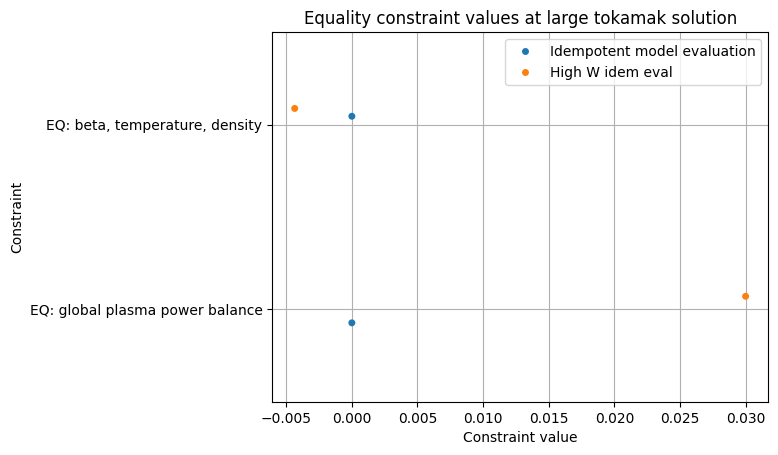

In [64]:
runs_metadata = [
    RunMetadata("lt_sol_MFILE.DAT", "Idempotent model evaluation"),
    RunMetadata("lt_sol_high_W_MFILE.DAT", "High W idem eval"),
]
ppb_fig, once_through_df = plot_mfile_solutions_constraints(
    runs_metadata=runs_metadata,
    title="Equality constraint values at large tokamak solution",
)

At the optimised solution vector, both constraints are satisfied. After the tungsten increase, both are violated. This is the starting point we want: a perturbation from an optimised solution.

## Can beta be solved as a fixed-point problem only?
Instead of calling models until idempotence is achieved, try running a fixed-point solver on beta only. `caller.py` modified on `process-fork`. `ioptizm = -2` still.

Try to visualise beta FPP. Run a 10 point scan of beta from within caller (difficult to run from nb; mods undone for subsequent work).

In [19]:
subprocess.run(
    "process -i lt_sol_fpp_IN.DAT".split(),
    capture_output=True,
    check=True,
)

CompletedProcess(args=['process', '-i', 'lt_sol_fpp_IN.DAT'], returncode=0, stdout=b"Running scipy's SLSQP\nThe IN.DAT file does not contain any obsolete variables.\n \n **************************************************************************************************************\n ************************************************** PROCESS ***************************************************\n ************************************** Power Reactor Optimisation Code ***************************************\n **************************************************************************************************************\n \n Version : 3.1.0\n Git Tag :\n Git Branch :\n Date : 11/08/2025 UTC\n Time : 14:04\n User : jon\n Computer : jon-Precision-3560\n Directory : /home/jon/code/notebooks/solutions_to_process/solutions_to_process_2\n Input : /home/jon/code/notebooks/solutions_to_process/solutions_to_process_2/lt_sol_fpp_IN.DAT\n Run title : generic large tokamak\n Run type : Reactor concept des

In [20]:
beta_prob_df = pd.read_csv("beta_fpp_problem.csv")
# beta_prob_df

Text(0.5, 1.0, 'Solution of $\\beta$ constraint at the LT solution')

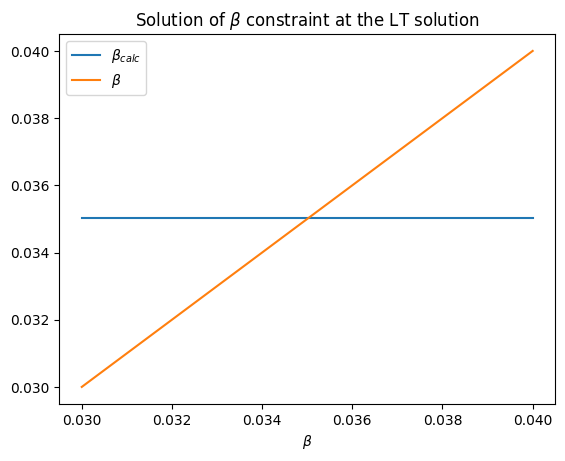

In [65]:
fig, ax = plt.subplots()
ax.plot(beta_prob_df["beta"], beta_prob_df["beta_calc"], label=r"$\beta_{calc}$")
ax.plot(beta_prob_df["beta"], beta_prob_df["beta"], label=r"$\beta$")
ax.set_xlabel(r"$\beta$")
ax.legend()
ax.set_title(r"Solution of $\beta$ constraint at the LT solution")

This shows that $\beta_{calc} \neq f(\beta)$. Therefore $\beta$ isn't a FPP.

Can beta be solved as an FPP though? Run high W case, solving for FPP. 2 constraints (beta and PPB), 0 iterations vars.

In [ ]:
subprocess.run(
    "process -i lt_sol_high_W_fpp_IN.DAT".split(),
    capture_output=True,
    check=True,
)

CompletedProcess(args=['process', '-i', 'lt_sol_high_W_fpp_IN.DAT'], returncode=0, stdout=b"Running scipy's SLSQP\nThe IN.DAT file does not contain any obsolete variables.\n \n **************************************************************************************************************\n ************************************************** PROCESS ***************************************************\n ************************************** Power Reactor Optimisation Code ***************************************\n **************************************************************************************************************\n \n Version : 3.1.0\n Git Tag :\n Git Branch :\n Date : 11/08/2025 UTC\n Time : 15:38\n User : jon\n Computer : jon-Precision-3560\n Directory : /home/jon/code/notebooks/solutions_to_process/solutions_to_process_2\n Input : /home/jon/code/notebooks/solutions_to_process/solutions_to_process_2/lt_sol_high_W_fpp_IN.DAT\n Run title : generic large tokamak\n Run type : React

Plot fixed-point problem results.

In [54]:
beta_df = pd.read_csv("beta_fpp.csv")
beta_df

,iteration,beta,beta_calc
0,0,0.035026,0.034875
1,1,0.034875,0.034873
2,2,0.034873,0.034873
3,3,0.034873,0.034873
4,4,0.034873,0.034873
5,5,0.034873,0.034873


Text(1.0, 0.035, 'Initial $\\beta$ from LT sol')

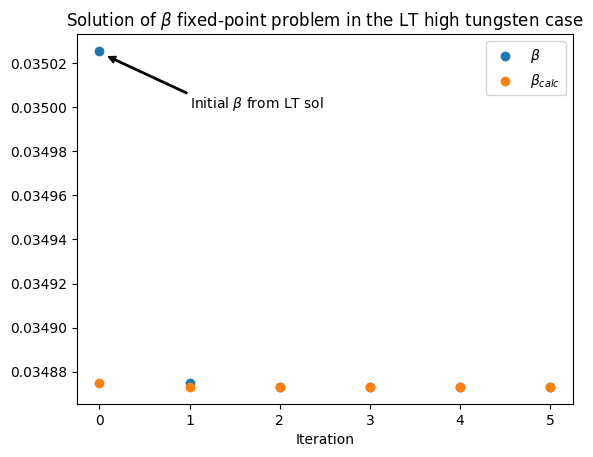

In [55]:
fig, ax = plt.subplots()
ax.scatter(beta_df["iteration"], beta_df["beta"], label=r"$\beta$")
ax.scatter(beta_df["iteration"], beta_df["beta_calc"], label=r"$\beta_{calc}$")
ax.set_xlabel("Iteration")
ax.legend()
ax.set_title(r"Solution of $\beta$ fixed-point problem in the LT high tungsten case")
ax.annotate(
    r"Initial $\beta$ from LT sol",
    (0.1, 0.035023),
    xytext=(1.0, 0.035),
    arrowprops={"width": 1, "color": "black", "headwidth": 5, "headlength": 5},
)

Beta converges as a fixed-point problem. This means it can be removed as a constraint equation and associated parameter.

Add to PPB fig.

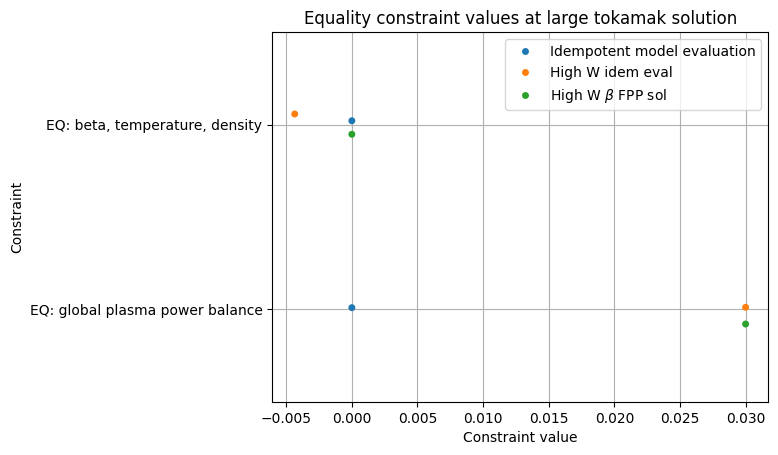

In [63]:
runs_metadata = [
    RunMetadata("lt_sol_MFILE.DAT", "Idempotent model evaluation"),
    RunMetadata("lt_sol_high_W_MFILE.DAT", "High W idem eval"),
    RunMetadata("lt_sol_high_W_fpp_MFILE.DAT", r"High W $\beta$ FPP sol"),
]
ppb_fig, once_through_df = plot_mfile_solutions_constraints(
    runs_metadata=runs_metadata,
    title="Equality constraint values at large tokamak solution",
)

## Solving PPB with various parameters
How can the PPB constraint be solved?

Need 2 eq cons in output, solve 1: needs rewiring.

Hack results in PPB solved, but beta not.

In [98]:
subprocess.run(
    "process -i lt_sol_high_W_fpp_ppb_IN.DAT".split(),
    capture_output=True,
    check=True,
)

CompletedProcess(args=['process', '-i', 'lt_sol_high_W_fpp_ppb_IN.DAT'], returncode=0, stdout=b"Running scipy's SLSQP\nThe IN.DAT file does not contain any obsolete variables.\n \n **************************************************************************************************************\n ************************************************** PROCESS ***************************************************\n ************************************** Power Reactor Optimisation Code ***************************************\n **************************************************************************************************************\n \n Version : 3.1.0\n Git Tag :\n Git Branch :\n Date : 12/08/2025 UTC\n Time : 15:28\n User : jon\n Computer : jon-Precision-3560\n Directory : /home/jon/code/notebooks/solutions_to_process/solutions_to_process_2\n Input : /home/jon/code/notebooks/solutions_to_process/solutions_to_process_2/lt_sol_high_W_fpp_ppb_IN.DAT\n Run title : generic large tokamak\n Run type

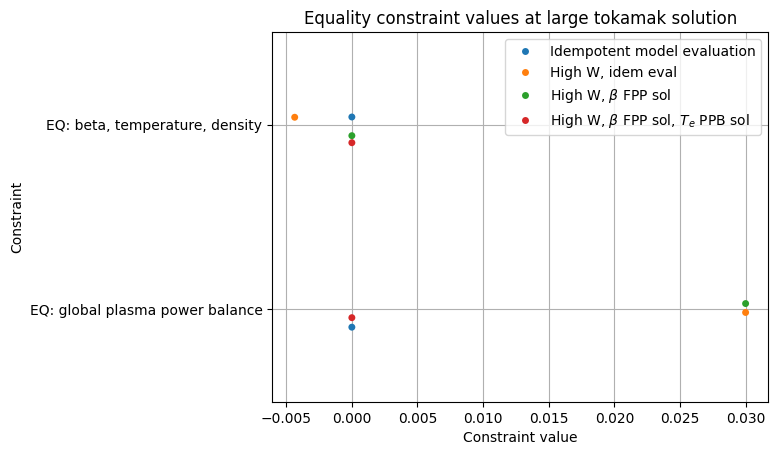

In [ ]:
runs_metadata = [
    RunMetadata("lt_sol_MFILE.DAT", "Idempotent model evaluation"),
    RunMetadata("lt_sol_high_W_MFILE.DAT", "High W, idem eval"),
    RunMetadata("lt_sol_high_W_fpp_MFILE.DAT", r"High W, $\beta$ FPP sol"),
    RunMetadata(
        "lt_sol_high_W_fpp_ppb_MFILE.DAT", r"High W, $\beta$ FPP sol, $T_e$ PPB sol"
    ),
]
ppb_fig, once_through_df = plot_mfile_solutions_constraints(
    runs_metadata=runs_metadata,
    title="Equality constraint values at large tokamak solution",
)

(Why is beta con being written out twice? Solution mode is part opt, part eval: both are writing out beta con, but one before final FPP soln, other after. Need to solve FPP in solver loop: now done.)

Beta and PPB are solved as an FPP in beta and for Te respectively.

## Solving PPB with different parameters
Te has been solved for already. Try solving for ne next.

In [100]:
subprocess.run(
    "process -i lt_sol_high_W_fpp_ppb_ne_IN.DAT".split(),
    capture_output=True,
    check=True,
)

CompletedProcess(args=['process', '-i', 'lt_sol_high_W_fpp_ppb_ne_IN.DAT'], returncode=0, stdout=b"Running scipy's SLSQP\nThe IN.DAT file does not contain any obsolete variables.\n \n **************************************************************************************************************\n ************************************************** PROCESS ***************************************************\n ************************************** Power Reactor Optimisation Code ***************************************\n **************************************************************************************************************\n \n Version : 3.1.0\n Git Tag :\n Git Branch :\n Date : 12/08/2025 UTC\n Time : 15:34\n User : jon\n Computer : jon-Precision-3560\n Directory : /home/jon/code/notebooks/solutions_to_process/solutions_to_process_2\n Input : /home/jon/code/notebooks/solutions_to_process/solutions_to_process_2/lt_sol_high_W_fpp_ppb_ne_IN.DAT\n Run title : generic large tokamak\n Ru

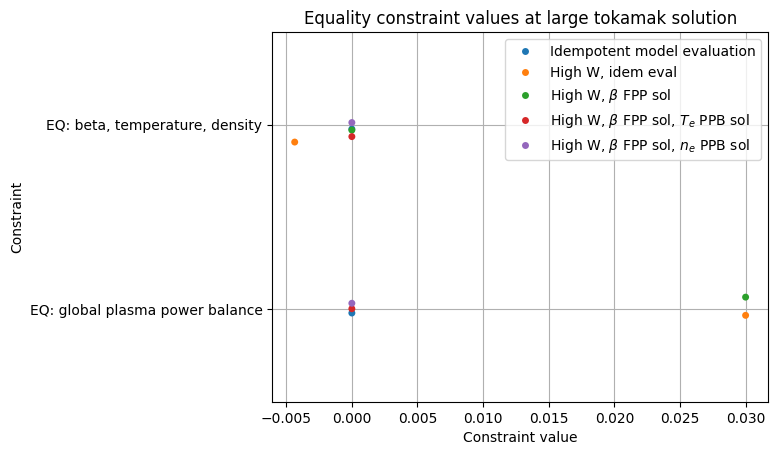

In [101]:
runs_metadata = [
    RunMetadata("lt_sol_MFILE.DAT", "Idempotent model evaluation"),
    RunMetadata("lt_sol_high_W_MFILE.DAT", "High W, idem eval"),
    RunMetadata("lt_sol_high_W_fpp_MFILE.DAT", r"High W, $\beta$ FPP sol"),
    RunMetadata(
        "lt_sol_high_W_fpp_ppb_MFILE.DAT", r"High W, $\beta$ FPP sol, $T_e$ PPB sol"
    ),
    RunMetadata(
        "lt_sol_high_W_fpp_ppb_ne_MFILE.DAT", r"High W, $\beta$ FPP sol, $n_e$ PPB sol"
    ),
]
ppb_fig, once_through_df = plot_mfile_solutions_constraints(
    runs_metadata=runs_metadata,
    title="Equality constraint values at large tokamak solution",
)

ne can solve. What about beta?

In [105]:
subprocess.run(
    "process -i lt_sol_high_W_fpp_ppb_beta_IN.DAT".split(),
    capture_output=True,
    check=True,
)

CompletedProcess(args=['process', '-i', 'lt_sol_high_W_fpp_ppb_beta_IN.DAT'], returncode=0, stdout=b"Running scipy's SLSQP\nThe IN.DAT file does not contain any obsolete variables.\n Warning in routine OCMMNT :\nInput : /home/jon/code/notebooks/solutions_to_process/solutions_to_process_2/lt_sol_high_W_fpp_ppb_beta_IN.DAT\nThis is longer than 110 columns.\n \n **************************************************************************************************************\n ************************************************** PROCESS ***************************************************\n ************************************** Power Reactor Optimisation Code ***************************************\n **************************************************************************************************************\n \n Version : 3.1.0\n Git Tag :\n Git Branch :\n Date : 12/08/2025 UTC\n Time : 15:38\n User : jon\n Computer : jon-Precision-3560\n Directory : /home/jon/code/notebooks/solutions_to_proc

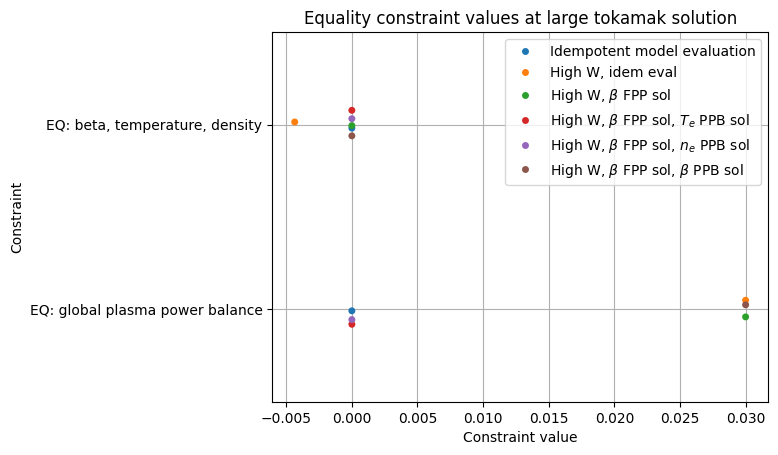

In [ ]:
runs_metadata = [
    RunMetadata("lt_sol_MFILE.DAT", "Idempotent model evaluation"),
    RunMetadata("lt_sol_high_W_MFILE.DAT", "High W, idem eval"),
    RunMetadata("lt_sol_high_W_fpp_MFILE.DAT", r"High W, $\beta$ FPP sol"),
    RunMetadata(
        "lt_sol_high_W_fpp_ppb_MFILE.DAT", r"High W, $\beta$ FPP sol, $T_e$ PPB sol"
    ),
    RunMetadata(
        "lt_sol_high_W_fpp_ppb_ne_MFILE.DAT", r"High W, $\beta$ FPP sol, $n_e$ PPB sol"
    ),
    RunMetadata(
        "lt_sol_high_W_fpp_ppb_beta_MFILE.DAT",
        r"High W, $\beta$ FPP sol, $\beta$ PPB sol",
    ),
]
ppb_fig, once_through_df = plot_mfile_solutions_constraints(
    runs_metadata=runs_metadata,
    title="Equality constraint values at large tokamak solution",
)

The beta case is interesting: solver and FPP problem will end up using different values of beta, hence solver think old value of beta solved PPB (when actually FPP did), and solver value wasn't updated, but constraints re-evaluataed there? Possibly. Fsolve and FPP fighting over same param: doesn't work.

What about another parameter?

In [133]:
subprocess.run(
    "process -i lt_sol_high_W_fpp_ppb_r0_IN.DAT".split(),
    capture_output=True,
    check=True,
)

CompletedProcess(args=['process', '-i', 'lt_sol_high_W_fpp_ppb_r0_IN.DAT'], returncode=0, stdout=b"Running scipy's SLSQP\nThe IN.DAT file does not contain any obsolete variables.\n \n **************************************************************************************************************\n ************************************************** PROCESS ***************************************************\n ************************************** Power Reactor Optimisation Code ***************************************\n **************************************************************************************************************\n \n Version : 3.1.0\n Git Tag :\n Git Branch :\n Date : 13/08/2025 UTC\n Time : 09:29\n User : jon\n Computer : jon-Precision-3560\n Directory : /home/jon/code/notebooks/solutions_to_process/solutions_to_process_2\n Input : /home/jon/code/notebooks/solutions_to_process/solutions_to_process_2/lt_sol_high_W_fpp_ppb_r0_IN.DAT\n Run title : generic large tokamak\n Ru

In [134]:
subprocess.run(
    "process -i lt_sol_high_W_fpp_ppb_c_he_IN.DAT".split(),
    capture_output=True,
    check=True,
)

CompletedProcess(args=['process', '-i', 'lt_sol_high_W_fpp_ppb_c_he_IN.DAT'], returncode=0, stdout=b"Running scipy's SLSQP\nThe IN.DAT file does not contain any obsolete variables.\n Warning in routine OCMMNT :\nInput : /home/jon/code/notebooks/solutions_to_process/solutions_to_process_2/lt_sol_high_W_fpp_ppb_c_he_IN.DAT\nThis is longer than 110 columns.\n \n **************************************************************************************************************\n ************************************************** PROCESS ***************************************************\n ************************************** Power Reactor Optimisation Code ***************************************\n **************************************************************************************************************\n \n Version : 3.1.0\n Git Tag :\n Git Branch :\n Date : 13/08/2025 UTC\n Time : 09:29\n User : jon\n Computer : jon-Precision-3560\n Directory : /home/jon/code/notebooks/solutions_to_proc

In [145]:
subprocess.run(
    "process -i lt_sol_high_W_fpp_ppb_hfact_IN.DAT".split(),
    capture_output=True,
    check=True,
)

CompletedProcess(args=['process', '-i', 'lt_sol_high_W_fpp_ppb_hfact_IN.DAT'], returncode=0, stdout=b"Running scipy's SLSQP\nThe IN.DAT file does not contain any obsolete variables.\n Warning in routine OCMMNT :\nInput : /home/jon/code/notebooks/solutions_to_process/solutions_to_process_2/lt_sol_high_W_fpp_ppb_hfact_IN.DAT\nThis is longer than 110 columns.\n \n **************************************************************************************************************\n ************************************************** PROCESS ***************************************************\n ************************************** Power Reactor Optimisation Code ***************************************\n **************************************************************************************************************\n \n Version : 3.1.0\n Git Tag :\n Git Branch :\n Date : 13/08/2025 UTC\n Time : 16:18\n User : jon\n Computer : jon-Precision-3560\n Directory : /home/jon/code/notebooks/solutions_to_pr

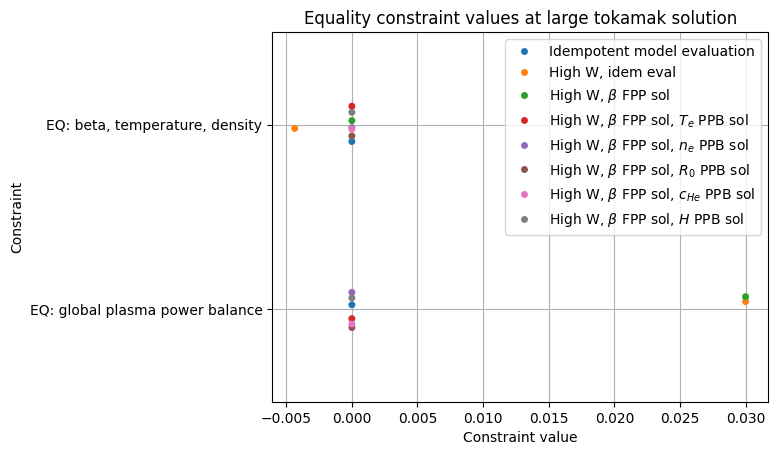

In [148]:
runs_metadata = [
    RunMetadata("lt_sol_MFILE.DAT", "Idempotent model evaluation"),
    RunMetadata("lt_sol_high_W_MFILE.DAT", "High W, idem eval"),
    RunMetadata("lt_sol_high_W_fpp_MFILE.DAT", r"High W, $\beta$ FPP sol"),
    RunMetadata(
        "lt_sol_high_W_fpp_ppb_MFILE.DAT", r"High W, $\beta$ FPP sol, $T_e$ PPB sol"
    ),
    RunMetadata(
        "lt_sol_high_W_fpp_ppb_ne_MFILE.DAT", r"High W, $\beta$ FPP sol, $n_e$ PPB sol"
    ),
    RunMetadata(
        "lt_sol_high_W_fpp_ppb_r0_MFILE.DAT", r"High W, $\beta$ FPP sol, $R_0$ PPB sol"
    ),
    RunMetadata(
        "lt_sol_high_W_fpp_ppb_c_he_MFILE.DAT",
        r"High W, $\beta$ FPP sol, $c_{He}$ PPB sol",
    ),
    RunMetadata(
        "lt_sol_high_W_fpp_ppb_hfact_MFILE.DAT",
        r"High W, $\beta$ FPP sol, $H$ PPB sol",
    ),
]

ppb_fig, once_through_df = plot_mfile_solutions_constraints(
    runs_metadata=runs_metadata,
    title="Equality constraint values at large tokamak solution",
)

Whilst clearly not a good idea, PPB can be solved with major radius.

Plot solution params.

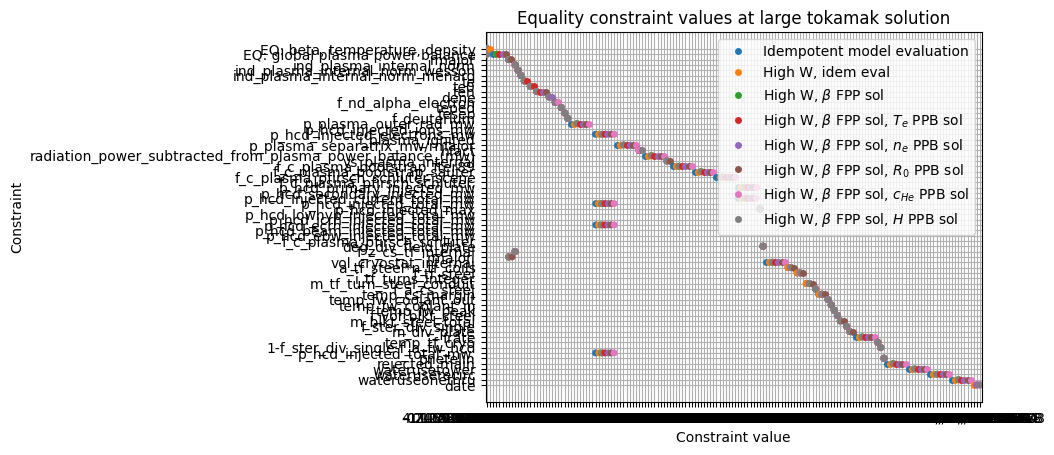

In [152]:
# Unpleasant, but get opt vars out in df
runs_metadata = [
    RunMetadata("lt_sol_MFILE.DAT", "Idempotent model evaluation"),
    RunMetadata("lt_sol_high_W_MFILE.DAT", "High W, idem eval"),
    RunMetadata("lt_sol_high_W_fpp_MFILE.DAT", r"High W, $\beta$ FPP sol"),
    RunMetadata(
        "lt_sol_high_W_fpp_ppb_MFILE.DAT", r"High W, $\beta$ FPP sol, $T_e$ PPB sol"
    ),
    RunMetadata(
        "lt_sol_high_W_fpp_ppb_ne_MFILE.DAT", r"High W, $\beta$ FPP sol, $n_e$ PPB sol"
    ),
    RunMetadata(
        "lt_sol_high_W_fpp_ppb_r0_MFILE.DAT", r"High W, $\beta$ FPP sol, $R_0$ PPB sol"
    ),
    RunMetadata(
        "lt_sol_high_W_fpp_ppb_c_he_MFILE.DAT",
        r"High W, $\beta$ FPP sol, $c_{He}$ PPB sol",
    ),
    RunMetadata(
        "lt_sol_high_W_fpp_ppb_hfact_MFILE.DAT",
        r"High W, $\beta$ FPP sol, $H$ PPB sol",
    ),
]
ppb_fig, once_through_df = plot_mfile_solutions_constraints(
    runs_metadata=runs_metadata,
    title="Equality constraint values at large tokamak solution",
    extra_var_names=["te", "dene", "rmajor", "f_nd_alpha_electron", "hfact"],
)

In [ ]:
sol_params_df = once_through_df[
    ["tag", "te", "dene", "rmajor", "f_nd_alpha_electron", "hfact"]
]

In [156]:
sol_params_interest_df = sol_params_df.loc[3:]
sol_params_interest_df

,tag,te,dene,rmajor,f_nd_alpha_electron,hfact
3,"High W, $\beta$ FPP sol, $T_e$ PPB sol",12.081070,8.285155e+19,8.000000,0.099411,1.200000
4,"High W, $\beta$ FPP sol, $n_e$ PPB sol",12.979123,7.383696e+19,8.000000,0.099411,1.200000
5,"High W, $\beta$ FPP sol, $R_0$ PPB sol",12.979123,8.285155e+19,8.681879,0.099411,1.200000
6,"High W, $\beta$ FPP sol, $c_{He}$ PPB sol",12.979123,8.285155e+19,8.000000,0.062651,1.200000
7,"High W, $\beta$ FPP sol, $H$ PPB sol",12.979123,8.285155e+19,8.000000,0.099411,1.255961


## tau_alpha / tau_E constraint
Can this be added as the second constraint?
Solve beta as FPP, then solve PPB and tau_alpha/tau_E for te and ne. Changed tau_alpha / tau_E to eq con.

In [6]:
subprocess.run(
    "process -i lt_sol_high_W_fpp_ppb_tau_alpha_IN.DAT".split(),
    capture_output=True,
    check=True,
)

CompletedProcess(args=['process', '-i', 'lt_sol_high_W_fpp_ppb_tau_alpha_IN.DAT'], returncode=0, stdout=b"Running scipy's SLSQP\nThe IN.DAT file does not contain any obsolete variables.\n Warning in routine OCMMNT :\nInput : /home/jon/code/notebooks/solutions_to_process/solutions_to_process_2/lt_sol_high_W_fpp_ppb_tau_alpha_IN.DAT\nThis is longer than 110 columns.\n \n **************************************************************************************************************\n ************************************************** PROCESS ***************************************************\n ************************************** Power Reactor Optimisation Code ***************************************\n **************************************************************************************************************\n \n Version : 3.1.0\n Git Tag :\n Git Branch :\n Date : 15/08/2025 UTC\n Time : 08:20\n User : jon\n Computer : jon-Precision-3560\n Directory : /home/jon/code/notebooks/solutio

Can't solve with `f_alpha_energy_confinement_min = 5.0`.

Finds soln with `f_alpha_energy_confinement_min = 7.28` (value taken from LT high W PPB te sol).

LT once through sol has f_alpha_energy_confinement_min = 7.28, should be 5. Process (not this fork) LT nof = 7.62. Process LT 6.76: con not active (not at min); should this be an eq?

### Run original LT with tau_alpha con as equality
On `slsqp-and-sol-mods` with only con 62 changed to equality.

In [ ]:
subprocess.run(
    "process -i lt_IN.DAT".split(),
    capture_output=True,
    check=True,
)

CompletedProcess(args=['process', '-i', 'lt_tau_alpha_sol_IN.DAT'], returncode=0, stdout=b"Running scipy's SLSQP\nThe IN.DAT file does not contain any obsolete variables.\n \n **************************************************************************************************************\n ************************************************** PROCESS ***************************************************\n ************************************** Power Reactor Optimisation Code ***************************************\n **************************************************************************************************************\n \n Version : 3.1.0\n Git Tag :\n Git Branch :\n Date : 15/08/2025 UTC\n Time : 09:26\n User : jon\n Computer : jon-Precision-3560\n Directory : /home/jon/code/notebooks/solutions_to_process/solutions_to_process_2\n Input : /home/jon/code/notebooks/solutions_to_process/solutions_to_process_2/lt_tau_alpha_sol_IN.DAT\n Run title : generic large tokamak\n Run type : Reactor

Got LT no f-value problem to converge with tau_alpha/tau_E = 5.0 (eq con). Convert to sol input: `lt_tau_alpha_sol_IN.DAT`. Run as solution problem.

In [15]:
subprocess.run(
    "process -i lt_tau_alpha_sol_IN.DAT".split(),
    capture_output=True,
    check=True,
)

CompletedProcess(args=['process', '-i', 'lt_tau_alpha_sol_IN.DAT'], returncode=0, stdout=b"Running scipy's SLSQP\nThe IN.DAT file does not contain any obsolete variables.\n \n **************************************************************************************************************\n ************************************************** PROCESS ***************************************************\n ************************************** Power Reactor Optimisation Code ***************************************\n **************************************************************************************************************\n \n Version : 3.1.0\n Git Tag :\n Git Branch :\n Date : 15/08/2025 UTC\n Time : 09:27\n User : jon\n Computer : jon-Precision-3560\n Directory : /home/jon/code/notebooks/solutions_to_process/solutions_to_process_2\n Input : /home/jon/code/notebooks/solutions_to_process/solutions_to_process_2/lt_tau_alpha_sol_IN.DAT\n Run title : generic large tokamak\n Run type : Reactor

Solution problem converges with all modifications: beta solved as FPP, PPB and tau_alpha solved with te and ne.

Perturb W, then try to resolve.

In [16]:
subprocess.run(
    "process -i lt_tau_alpha_sol_high_W_IN.DAT".split(),
    capture_output=True,
    check=True,
)

CompletedProcess(args=['process', '-i', 'lt_tau_alpha_sol_high_W_IN.DAT'], returncode=0, stdout=b"Running scipy's SLSQP\nThe IN.DAT file does not contain any obsolete variables.\n \n **************************************************************************************************************\n ************************************************** PROCESS ***************************************************\n ************************************** Power Reactor Optimisation Code ***************************************\n **************************************************************************************************************\n \n Version : 3.1.0\n Git Tag :\n Git Branch :\n Date : 15/08/2025 UTC\n Time : 09:30\n User : jon\n Computer : jon-Precision-3560\n Directory : /home/jon/code/notebooks/solutions_to_process/solutions_to_process_2\n Input : /home/jon/code/notebooks/solutions_to_process/solutions_to_process_2/lt_tau_alpha_sol_high_W_IN.DAT\n Run title : generic large tokamak\n Run 

This solves: determined problem solved for high W case.

### Plot ne, te for sols with increasing W

In [ ]:
w_fracs = np.linspace(5e-6, 1e-4, 20)
sol_data = {
    "w": w_fracs,
    "te": [],
    "ne": [],
    "tau_alpha": [],
    "tau_e": [],
    "beta": [],
}
for w_frac in w_fracs:
    single_run = SingleRun("lt_tau_alpha_sol_high_W_IN.DAT")
    process.fortran.impurity_radiation_module.impurity_arr_frac[13] = w_frac
    single_run.run()
    sol_data["te"].append(process.fortran.physics_variables.te.item())
    sol_data["ne"].append(process.fortran.physics_variables.dene.item())
    sol_data["tau_alpha"].append(
        process.fortran.physics_variables.t_alpha_confinement.item()
    )
    sol_data["tau_e"].append(
        process.fortran.physics_variables.t_energy_confinement.item()
    )
    sol_data["beta"].append(process.fortran.physics_variables.beta.item())

/home/jon/code/process-fork/process/init.py:80: UserWarning: tmargmin_cs and tmargmin should not both be specified in IN.DAT tmargmin_cs has been ignored
  check_process(inputs)
/home/jon/code/process-fork/process/physics.py:7258: RuntimeWarning: divide by zero encountered in divide
  * (neped / n_greenwald) ** -0.174
process.pfcoil - WARNING - Ratio of central solenoid overall current density at beginning of flat-top / end of flat-top > 1 (|f_j_cs_start_end_flat_top| > 1)


The IN.DAT file does not contain any obsolete variables.
 
 **************************************************************************************************************
 ************************************************** PROCESS ***************************************************
 ************************************** Power Reactor Optimisation Code ***************************************
 **************************************************************************************************************
 
 Version : 3.1.0
 Git Tag :
 Git Branch :
Solving equality constraints using fsolve
 Date : 15/08/2025 UTC
 Time : 12:44
 User : jon
 Computer : jon-Precision-3560
 Directory : /home/jon/code/notebooks/solutions_to_process/solutions_to_process_2
 Input : /home/jon/code/notebooks/solutions_to_process/solutions_to_process_2/lt_tau_alpha_sol_high_W_IN.DAT
 Run title : generic large tokamak
 Run type : Reactor concept design: Pulsed tokamak model model, (c) UK Atomic Energy Authority
 
 ***

/home/jon/code/process-fork/process/costs.py:2808: RuntimeWarning: invalid value encountered in sqrt
  annoam = cost_variables.ucoam[cost_variables.lsa - 1] * np.sqrt(
/home/jon/code/process-fork/process/costs.py:2879: RuntimeWarning: invalid value encountered in sqrt
  annwst = cost_variables.ucwst[cost_variables.lsa - 1] * np.sqrt(
process.pfcoil - WARNING - Ratio of central solenoid overall current density at beginning of flat-top / end of flat-top > 1 (|f_j_cs_start_end_flat_top| > 1)


 
 ************************************ PROCESS found a consistent solution *************************************
 
 Warning in routine OCMMNT :

*Cryostat roof allowance includes uppermost PF coil and outer thermal shield.
*Cryostat floor allowance includes lowermost PF coil, outer thermal shield and gravity support.
This is longer than 110 columns.
 
 ******************************************** Errors and Warnings *********************************************
 
 PROCESS status flag:   Warning messages                                  
 
 ID  LEVEL  MESSAGE
244     2   PHYSICS: Diamagnetic fraction is more than 1%, but not calculated. Consider usin
  
135     1   OUTPF: CS not using max current density: further optimisation may be possible   
  
286     2   [pfcoil][cntrpost]: fjohc shouldn't be above 0.7 for engineering reliability.   
  
287     2   [pfcoil][cntrpost]: fjohc0 shouldn't be above 0.7 for engineering reliability.  
  
 *************************************************

process.pfcoil - WARNING - Ratio of central solenoid overall current density at beginning of flat-top / end of flat-top > 1 (|f_j_cs_start_end_flat_top| > 1)


...

 
 ************************************ PROCESS found a consistent solution *************************************
 
 Warning in routine OCMMNT :

*Cryostat roof allowance includes uppermost PF coil and outer thermal shield.
*Cryostat floor allowance includes lowermost PF coil, outer thermal shield and gravity support.
This is longer than 110 columns.
 
 ******************************************** Errors and Warnings *********************************************
 
 PROCESS status flag:   Warning messages                                  
 
 ID  LEVEL  MESSAGE
244     2   PHYSICS: Diamagnetic fraction is more than 1%, but not calculated. Consider usin
  
135     1   OUTPF: CS not using max current density: further optimisation may be possible   
  
286     2   [pfcoil][cntrpost]: fjohc shouldn't be above 0.7 for engineering reliability.   
  
287     2   [pfcoil][cntrpost]: fjohc0 shouldn't be above 0.7 for engineering reliability.  
  
 *************************************************

process.pfcoil - WARNING - Ratio of central solenoid overall current density at beginning of flat-top / end of flat-top > 1 (|f_j_cs_start_end_flat_top| > 1)


 
 ************************************ PROCESS found a consistent solution *************************************
 
 Warning in routine OCMMNT :

*Cryostat roof allowance includes uppermost PF coil and outer thermal shield.
*Cryostat floor allowance includes lowermost PF coil, outer thermal shield and gravity support.
This is longer than 110 columns.
 
 ******************************************** Errors and Warnings *********************************************
 
 PROCESS status flag:   Warning messages                                  
 
 ID  LEVEL  MESSAGE
244     2   PHYSICS: Diamagnetic fraction is more than 1%, but not calculated. Consider usin
  
135     1   OUTPF: CS not using max current density: further optimisation may be possible   
  
286     2   [pfcoil][cntrpost]: fjohc shouldn't be above 0.7 for engineering reliability.   
  
287     2   [pfcoil][cntrpost]: fjohc0 shouldn't be above 0.7 for engineering reliability.  
  
 *************************************************

process.pfcoil - WARNING - Ratio of central solenoid overall current density at beginning of flat-top / end of flat-top > 1 (|f_j_cs_start_end_flat_top| > 1)


 
 ************************************ PROCESS found a consistent solution *************************************
 
 Warning in routine OCMMNT :

*Cryostat roof allowance includes uppermost PF coil and outer thermal shield.
*Cryostat floor allowance includes lowermost PF coil, outer thermal shield and gravity support.
This is longer than 110 columns.
 
 ******************************************** Errors and Warnings *********************************************
 
 PROCESS status flag:   Warning messages                                  
 
 ID  LEVEL  MESSAGE
244     2   PHYSICS: Diamagnetic fraction is more than 1%, but not calculated. Consider usin
  
135     1   OUTPF: CS not using max current density: further optimisation may be possible   
  
286     2   [pfcoil][cntrpost]: fjohc shouldn't be above 0.7 for engineering reliability.   
  
287     2   [pfcoil][cntrpost]: fjohc0 shouldn't be above 0.7 for engineering reliability.  
  
 *************************************************

In [86]:
w_ne_te_df = pd.DataFrame(sol_data)
w_ne_te_df

,w,te,ne,tau_alpha,tau_e,beta
0,0.000005,12.597628,7.855372e+19,14.583382,2.916676,0.037903
1,0.000010,12.569019,7.842931e+19,14.690952,2.938190,0.037715
2,0.000015,12.540070,7.830453e+19,14.800522,2.960104,0.037527
3,0.000020,12.510768,7.817936e+19,14.912172,2.982434,0.037337
4,0.000025,12.481103,7.805380e+19,15.025971,3.005194,0.037147
5,0.000030,12.451063,7.792784e+19,15.142001,3.028400,0.036956
6,0.000035,12.420633,7.780148e+19,15.260350,3.052070,0.036763
7,0.000040,12.389802,7.767462e+19,15.381106,3.076221,0.036570
8,0.000045,12.358555,7.754718e+19,15.504374,3.100875,0.036375
9,0.000050,12.326876,7.741931e+19,15.630242,3.126048,0.036180


Text(12.25, 7.83e+19, 'Initial optimised sol\nW frac = 5.0e-6')

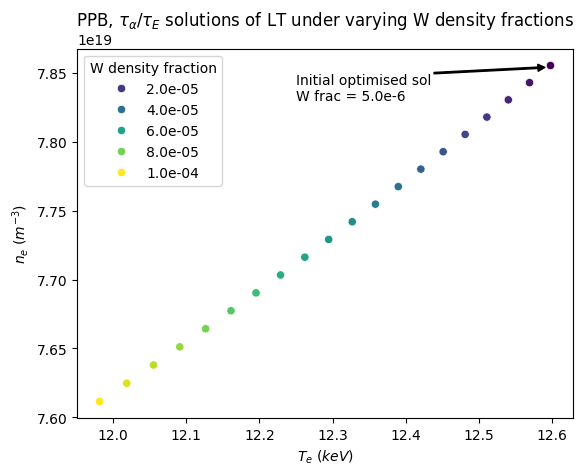

In [ ]:
ax = sns.scatterplot(data=w_ne_te_df, x="te", y="ne", hue="w", palette="viridis")
handles, labels = ax.get_legend_handles_labels()
legend = ax.legend(handles, [f"{float(l):.1e}" for l in labels])
legend.set_title("W density fraction")
ax.set_ylabel("$n_e$ $(m^{-3})$")
ax.set_xlabel("$T_e$ $(keV)$")
ax.set_title(
    r"PPB, $\tau_{\alpha}/\tau_E$ solutions of LT under varying W density fractions"
)
ax.annotate(
    "Initial optimised sol\nW frac = 5.0e-6",
    (12.59, 7.854e19),
    xytext=(12.25, 7.83e19),
    arrowprops={"width": 1, "color": "black", "headwidth": 5, "headlength": 5},
)

Plot confinement times and other vars of interest.

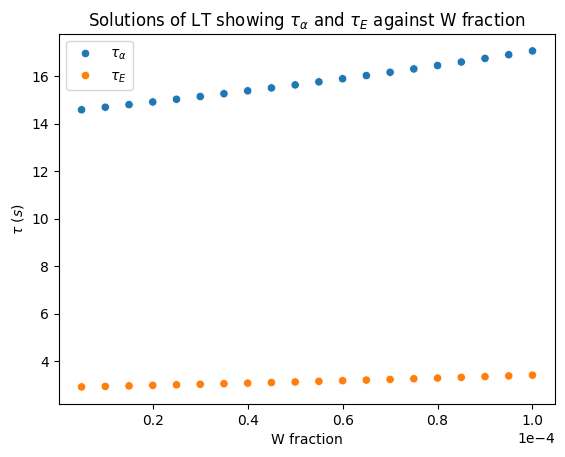

In [ ]:
w_tau_alpha_tau_e_sol_ppb_tau_alpha_df_melt = w_ne_te_df[
    ["w", "tau_alpha", "tau_e"]
].melt(id_vars="w")
ax = sns.scatterplot(
    data=w_tau_alpha_tau_e_sol_ppb_tau_alpha_df_melt, x="w", y="value", hue="variable"
)
ax.set_xlabel("W fraction")
ax.set_ylabel(r"$\tau$ $(s)$")
handles, labels = ax.get_legend_handles_labels()
my_map = {"tau_alpha": r"$\tau_{\alpha}$", "tau_e": r"$\tau_E$"}
ax.legend(handles, [my_map[l] for l in labels])
ax.set_title(
    r"Solutions of LT showing $\tau_{\alpha}$ and $\tau_{E}$ against W fraction"
)
ax.ticklabel_format(style="sci", axis="x", scilimits=(0, 0))

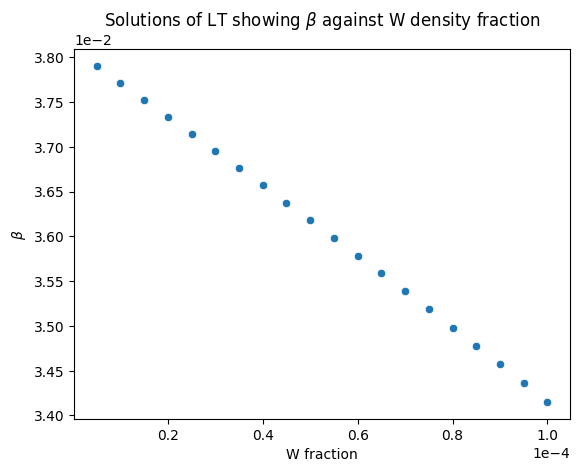

In [117]:
ax = sns.scatterplot(data=w_ne_te_df, x="w", y="beta")
handles, labels = ax.get_legend_handles_labels()
# legend = ax.legend(handles, [f"{float(l):.2e}" for l in labels])
# legend.set_title("W density fraction")
ax.set_ylabel(r"$\beta$")
ax.set_xlabel("W fraction")
ax.set_title(r"Solutions of LT showing $\beta$ against W density fraction")
# ax.annotate(
#     "Initial sol W frac\n= 5.0e-6",
#     (12.59, 7.854e19),
#     xytext=(12.3, 7.83e19),
#     arrowprops={"width": 1, "color": "black", "headwidth": 5, "headlength": 5},
# )
ax.ticklabel_format(style="sci", axis="x", scilimits=(0, 0))
ax.ticklabel_format(style="sci", axis="y", scilimits=(0, 0))

## tau_E with W experiment
### Evaluate only
See how confinement time equation varies with W frac. Evaluate only.

In [2]:
# Extend range again
w_fracs = np.linspace(5e-6, 1e-4, 20)
tau_e_eval_data = {
    "w": w_fracs,
    "tau_e_scaling_hfact": [],
    "tau_e_beta": [],
    "w_th": [],
    "p_heat": [],
    "p_rad": [],
    "te": [],
    "ne": [],
    "h": [],
    "nttau": [],
}
for w_frac in w_fracs:
    # Evaluation run only
    single_run = SingleRun("lt_tau_alpha_sol_eval_IN.DAT")
    process.fortran.impurity_radiation_module.impurity_arr_frac[13] = w_frac
    single_run.run()
    tau_e_eval_data["tau_e_scaling_hfact"].append(
        process.fortran.physics_variables.t_energy_confinement.item()
    )
    tau_e_eval_data["tau_e_beta"].append(
        process.fortran.physics_module.t_energy_confinement_beta.item()
    )
    tau_e_eval_data["w_th"].append(
        process.fortran.physics_module.e_plasma_beta.item() / 1e6
    )
    # Calc P_rad
    p_rad = (
        process.fortran.physics_variables.pden_plasma_core_rad_mw.item()
        * process.fortran.physics_variables.vol_plasma.item()
    )
    tau_e_eval_data["p_heat"].append(
        process.fortran.physics_variables.p_plasma_loss_mw.item() + p_rad
    )
    tau_e_eval_data["p_rad"].append(p_rad)
    tau_e_eval_data["te"].append(process.fortran.physics_variables.te.item())
    tau_e_eval_data["ne"].append(process.fortran.physics_variables.dene.item())
    tau_e_eval_data["h"].append(process.fortran.physics_variables.hfact.item())
    tau_e_eval_data["nttau"].append(process.fortran.physics_variables.nTtau.item())

The IN.DAT file does not contain any obsolete variables.
 
 **************************************************************************************************************
 ************************************************** PROCESS ***************************************************
 ************************************** Power Reactor Optimisation Code ***************************************
 **************************************************************************************************************
 
 Version : 3.1.0
 Git Tag :
 Git Branch :
 Date : 22/08/2025 UTC
 Time : 09:54
 User : jon
 Computer : jon-Precision-3560
 Directory : /home/jon/code/notebooks/solutions_to_process/solutions_to_process_2
 Input : /home/jon/code/notebooks/solutions_to_process/solutions_to_process_2/lt_tau_alpha_sol_eval_IN.DAT
 Run title : generic large tokamak
 Run type : Reactor concept design: Pulsed tokamak model model, (c) UK Atomic Energy Authority
 
 ***********************************************

/home/jon/anaconda3/envs/solns2/lib/python3.11/site-packages/process/init.py:80: UserWarning: tmargmin_cs and tmargmin should not both be specified in IN.DAT tmargmin_cs has been ignored
  check_process(inputs)
/home/jon/anaconda3/envs/solns2/lib/python3.11/site-packages/process/physics.py:7259: RuntimeWarning: divide by zero encountered in divide
  * (neped / n_greenwald) ** -0.174
process.pfcoil - WARNING - Ratio of central solenoid overall current density at beginning of flat-top / end of flat-top > 1 (|f_j_cs_start_end_flat_top| > 1)
/home/jon/anaconda3/envs/solns2/lib/python3.11/site-packages/process/costs.py:2808: RuntimeWarning: invalid value encountered in sqrt
  annoam = cost_variables.ucoam[cost_variables.lsa - 1] * np.sqrt(
/home/jon/anaconda3/envs/solns2/lib/python3.11/site-packages/process/costs.py:2879: RuntimeWarning: invalid value encountered in sqrt
  annwst = cost_variables.ucwst[cost_variables.lsa - 1] * np.sqrt(
process.power - ERROR - ERROR Negative stored energy i

 Warning in routine OCMMNT :

*Cryostat roof allowance includes uppermost PF coil and outer thermal shield.
*Cryostat floor allowance includes lowermost PF coil, outer thermal shield and gravity support.
This is longer than 110 columns.
 Warning in routine OCMMNT :

*Cryostat roof allowance includes uppermost PF coil and outer thermal shield.
*Cryostat floor allowance includes lowermost PF coil, outer thermal shield and gravity support.
This is longer than 110 columns.
 Warning in routine OCMMNT :

*Cryostat roof allowance includes uppermost PF coil and outer thermal shield.
*Cryostat floor allowance includes lowermost PF coil, outer thermal shield and gravity support.
This is longer than 110 columns.
 Warning in routine OCMMNT :

*Cryostat roof allowance includes uppermost PF coil and outer thermal shield.
*Cryostat floor allowance includes lowermost PF coil, outer thermal shield and gravity support.
This is longer than 110 columns.
 Warning in routine OCMMNT :

*Cryostat roof allowan

/home/jon/anaconda3/envs/solns2/lib/python3.11/site-packages/process/init.py:80: UserWarning: tmargmin_cs and tmargmin should not both be specified in IN.DAT tmargmin_cs has been ignored
  check_process(inputs)
/home/jon/anaconda3/envs/solns2/lib/python3.11/site-packages/process/physics.py:7259: RuntimeWarning: divide by zero encountered in divide
  * (neped / n_greenwald) ** -0.174
process.pfcoil - WARNING - Ratio of central solenoid overall current density at beginning of flat-top / end of flat-top > 1 (|f_j_cs_start_end_flat_top| > 1)
process.power - ERROR - ERROR Negative stored energy in poloidal field


 
 **************************************************************************************************************
 ************************************************** PROCESS ***************************************************
 ************************************** Power Reactor Optimisation Code ***************************************
 **************************************************************************************************************
 
 Version : 3.1.0
 Git Tag :
 Git Branch :
 Date : 22/08/2025 UTC
 Time : 09:54
 User : jon
 Computer : jon-Precision-3560
 Directory : /home/jon/code/notebooks/solutions_to_process/solutions_to_process_2
 Input : /home/jon/code/notebooks/solutions_to_process/solutions_to_process_2/lt_tau_alpha_sol_eval_IN.DAT
 Run title : generic large tokamak
 Run type : Reactor concept design: Pulsed tokamak model model, (c) UK Atomic Energy Authority
 
 ********************************************************************************************************

...

 Warning in routine OCMMNT :

*Cryostat roof allowance includes uppermost PF coil and outer thermal shield.
*Cryostat floor allowance includes lowermost PF coil, outer thermal shield and gravity support.
This is longer than 110 columns.
 Warning in routine OCMMNT :

*Cryostat roof allowance includes uppermost PF coil and outer thermal shield.
*Cryostat floor allowance includes lowermost PF coil, outer thermal shield and gravity support.
This is longer than 110 columns.
 
 ******************************************** Errors and Warnings *********************************************
 
 PROCESS status flag:   Warning messages                                  
 
 ID  LEVEL  MESSAGE
244     2   PHYSICS: Diamagnetic fraction is more than 1%, but not calculated. Consider usin
  
 93     2   BURN: Negative burn time available; reduce t_fusion_ramp or raise PF coil V-s ca
 Floating point diagnostic values for this error:
   1)   -8.11164E+05
   2)   -3.46447E+04
   3)    4.27104E-02
   4)    1.

process.power - ERROR - ERROR Negative stored energy in poloidal field
process.power - WARNING - WARNING: Power balance across separatrix is in error by more than 5 MW.
process.power - WARNING - WARNING: Power balance across separatrix is in error by more than 5 MW.
process.power - WARNING - WARNING: Power balance across separatrix is in error by more than 5 MW.


 Warning in routine OCMMNT :

*Cryostat roof allowance includes uppermost PF coil and outer thermal shield.
*Cryostat floor allowance includes lowermost PF coil, outer thermal shield and gravity support.
This is longer than 110 columns.
 Warning in routine OCMMNT :

*Cryostat roof allowance includes uppermost PF coil and outer thermal shield.
*Cryostat floor allowance includes lowermost PF coil, outer thermal shield and gravity support.
This is longer than 110 columns.
 Warning in routine OCMMNT :

*Cryostat roof allowance includes uppermost PF coil and outer thermal shield.
*Cryostat floor allowance includes lowermost PF coil, outer thermal shield and gravity support.
This is longer than 110 columns.


process.power - WARNING - WARNING: Power balance across separatrix is in error by more than 5 MW.
process.power - WARNING - WARNING: Power balance across separatrix is in error by more than 5 MW.
process.power - WARNING - WARNING: Power balance across separatrix is in error by more than 5 MW.


 Warning in routine OCMMNT :

*Cryostat roof allowance includes uppermost PF coil and outer thermal shield.
*Cryostat floor allowance includes lowermost PF coil, outer thermal shield and gravity support.
This is longer than 110 columns.
 Warning in routine OCMMNT :

*Cryostat roof allowance includes uppermost PF coil and outer thermal shield.
*Cryostat floor allowance includes lowermost PF coil, outer thermal shield and gravity support.
This is longer than 110 columns.
 
 ******************************************** Errors and Warnings *********************************************
 
 PROCESS status flag:   Warning messages                                  
 
 ID  LEVEL  MESSAGE
244     2   PHYSICS: Diamagnetic fraction is more than 1%, but not calculated. Consider usin
  
 93     2   BURN: Negative burn time available; reduce t_fusion_ramp or raise PF coil V-s ca
 Floating point diagnostic values for this error:
   1)   -8.06980E+05
   2)   -3.46447E+04
   3)    4.29318E-02
   4)    1.

In [3]:
tau_e_eval_df = pd.DataFrame(tau_e_eval_data)
# tau_e_eval_df

Text(0.5, 0.98, 'Evaluations of LT against W fraction')

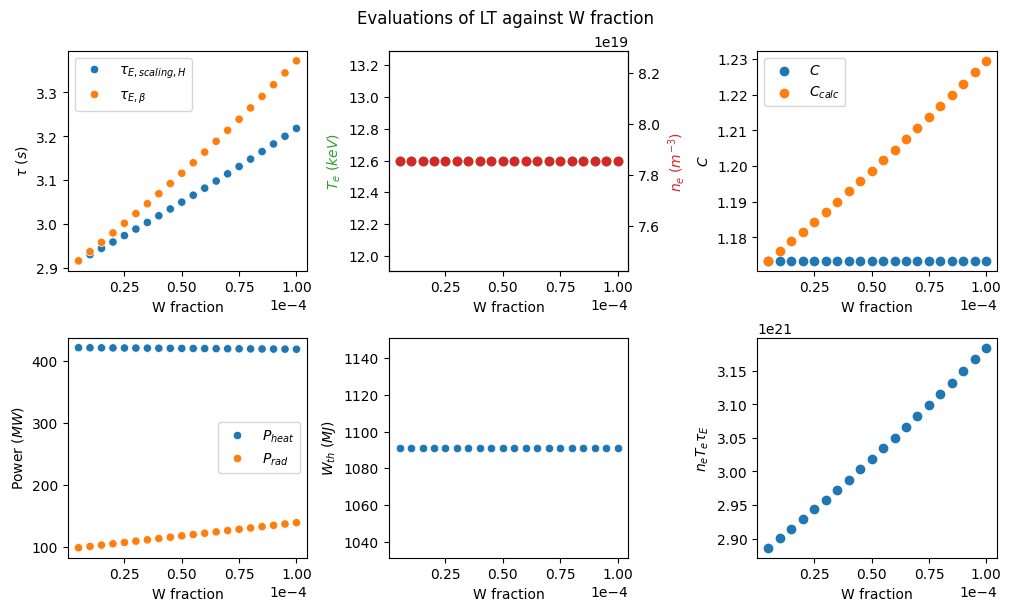

In [6]:
tau_e_eval_df_melt = tau_e_eval_df.melt(id_vars="w")
fig, ax = plt.subplots(ncols=3, nrows=2, layout="constrained")
fig.set_size_inches(10, 6)

# tau_E plot
ax0 = sns.scatterplot(
    data=tau_e_eval_df_melt[
        tau_e_eval_df_melt["variable"].isin(["tau_e_scaling_hfact", "tau_e_beta"])
    ],
    x="w",
    y="value",
    hue="variable",
    ax=ax[0, 0],
)
ax0.set_xlabel("W fraction")
ax0.set_ylabel(r"$\tau$ $(s)$")
handles, labels = ax0.get_legend_handles_labels()
my_map = {
    "tau_e_scaling_hfact": r"$\tau_{E, scaling, H}$",
    "tau_e_beta": r"$\tau_{E, \beta}$",
}
ax0.legend(handles, [my_map[l] for l in labels])
ax0.ticklabel_format(style="sci", axis="x", scilimits=(0, 0))

# te, ne plot
ax[0, 1].scatter(tau_e_eval_df["w"], tau_e_eval_df["te"], c="C2")
ax[0, 1].set_xlabel("W fraction")
ax[0, 1].set_ylabel(r"$T_e$ $(keV)$", c="C2")
ax[0, 1].ticklabel_format(style="sci", axis="x", scilimits=(0, 0))
ax1_right = ax[0, 1].twinx()
ax1_right.scatter(tau_e_eval_df["w"], tau_e_eval_df["ne"], c="C3")
ax1_right.set_ylabel(r"$n_e$ $(m^{-3})$", c="C3")

# Power plot
ax2 = sns.scatterplot(
    data=tau_e_eval_df_melt[tau_e_eval_df_melt["variable"].isin(["p_heat", "p_rad"])],
    x="w",
    y="value",
    hue="variable",
    ax=ax[1, 0],
)
ax2.set_xlabel("W fraction")
ax2.set_ylabel(r"Power $(MW)$")
handles, labels = ax2.get_legend_handles_labels()
my_map = {"p_heat": r"$P_{heat}$", "p_rad": r"$P_{rad}$"}
ax2.legend(handles, [my_map[l] for l in labels])
ax2.ticklabel_format(style="sci", axis="x", scilimits=(0, 0))

# Te, ne plot
ax3 = sns.scatterplot(
    data=tau_e_eval_df_melt[tau_e_eval_df_melt["variable"].isin(["w_th"])],
    x="w",
    y="value",
    ax=ax[1, 1],
)
ax3.ticklabel_format(style="sci", axis="x", scilimits=(0, 0))
ax3.set_xlabel("W fraction")
ax3.set_ylabel(r"$W_{th}$ $(MJ)$")

# C and C_calc plot
tau_e_scaling_hfact = tau_e_eval_df["tau_e_scaling_hfact"].to_numpy()
h = tau_e_eval_df["h"].to_numpy()
# Get scaling tau back
tau_e_scaling = tau_e_scaling_hfact / h
tau_e_beta = tau_e_eval_df["tau_e_beta"].to_numpy()
w = tau_e_eval_df["w"].to_numpy()
h_calc = tau_e_beta / tau_e_scaling

ax[0, 2].scatter(w, h, label="$C$")
ax[0, 2].scatter(w, h_calc, label="$C_{calc}$")
ax[0, 2].ticklabel_format(style="sci", axis="x", scilimits=(0, 0))
ax[0, 2].set_xlabel("W fraction")
ax[0, 2].set_ylabel(r"$C$")
ax[0, 2].legend()

# nttau plot
ax[1, 2].scatter(w, tau_e_eval_df["nttau"])
ax[1, 2].ticklabel_format(style="sci", axis="x", scilimits=(0, 0))
ax[1, 2].set_xlabel("W fraction")
ax[1, 2].set_ylabel(r"$n_e T_e \tau_E$")

fig.suptitle(r"Evaluations of LT against W fraction")

### Solving for C

In [ ]:
# Extend range again
w_fracs = np.linspace(5e-6, 1e-4, 20)
tau_e_sol_c_data = {
    "w": w_fracs,
    "tau_e_scaling_hfact": [],
    "tau_e_beta": [],
    "w_th": [],
    "p_heat": [],
    "p_rad": [],
    "te": [],
    "ne": [],
    "h": [],
    "nttau": [],
}
for w_frac in w_fracs:
    # Evaluation run only
    single_run = SingleRun("lt_tau_alpha_sol_sol_c_IN.DAT")
    process.fortran.impurity_radiation_module.impurity_arr_frac[13] = w_frac
    single_run.run()
    tau_e_sol_c_data["tau_e_scaling_hfact"].append(
        process.fortran.physics_variables.t_energy_confinement.item()
    )
    tau_e_sol_c_data["tau_e_beta"].append(
        process.fortran.physics_module.t_energy_confinement_beta.item()
    )
    tau_e_sol_c_data["w_th"].append(
        process.fortran.physics_module.e_plasma_beta.item() / 1e6
    )
    # Calc P_rad
    p_rad = (
        process.fortran.physics_variables.pden_plasma_core_rad_mw.item()
        * process.fortran.physics_variables.vol_plasma.item()
    )
    tau_e_sol_c_data["p_heat"].append(
        process.fortran.physics_variables.p_plasma_loss_mw.item() + p_rad
    )
    tau_e_sol_c_data["p_rad"].append(p_rad)
    tau_e_sol_c_data["te"].append(process.fortran.physics_variables.te.item())
    tau_e_sol_c_data["ne"].append(process.fortran.physics_variables.dene.item())
    tau_e_sol_c_data["h"].append(process.fortran.physics_variables.hfact.item())
    tau_e_sol_c_data["nttau"].append(process.fortran.physics_variables.nTtau.item())

/home/jon/anaconda3/envs/solns2/lib/python3.11/site-packages/process/init.py:80: UserWarning: tmargmin_cs and tmargmin should not both be specified in IN.DAT tmargmin_cs has been ignored
  check_process(inputs)
/home/jon/anaconda3/envs/solns2/lib/python3.11/site-packages/process/physics.py:7259: RuntimeWarning: divide by zero encountered in divide
  * (neped / n_greenwald) ** -0.174
process.pfcoil - WARNING - Ratio of central solenoid overall current density at beginning of flat-top / end of flat-top > 1 (|f_j_cs_start_end_flat_top| > 1)


The IN.DAT file does not contain any obsolete variables.
 
 **************************************************************************************************************
 ************************************************** PROCESS ***************************************************
 ************************************** Power Reactor Optimisation Code ***************************************
 **************************************************************************************************************
 
 Version : 3.1.0
 Git Tag :
 Git Branch :
Solving equality constraints using fsolve
 Date : 22/08/2025 UTC
 Time : 09:59
 User : jon
 Computer : jon-Precision-3560
 Directory : /home/jon/code/notebooks/solutions_to_process/solutions_to_process_2
 Input : /home/jon/code/notebooks/solutions_to_process/solutions_to_process_2/lt_tau_alpha_sol_sol_c_IN.DAT
 Run title : generic large tokamak
 Run type : Reactor concept design: Pulsed tokamak model model, (c) UK Atomic Energy Authority
 
 ****

/home/jon/anaconda3/envs/solns2/lib/python3.11/site-packages/process/costs.py:2808: RuntimeWarning: invalid value encountered in sqrt
  annoam = cost_variables.ucoam[cost_variables.lsa - 1] * np.sqrt(
/home/jon/anaconda3/envs/solns2/lib/python3.11/site-packages/process/costs.py:2879: RuntimeWarning: invalid value encountered in sqrt
  annwst = cost_variables.ucwst[cost_variables.lsa - 1] * np.sqrt(


 
 ************************************ PROCESS found a consistent solution *************************************
 
 Warning in routine OCMMNT :

*Cryostat roof allowance includes uppermost PF coil and outer thermal shield.
*Cryostat floor allowance includes lowermost PF coil, outer thermal shield and gravity support.
This is longer than 110 columns.
 Warning in routine OCMMNT :

*Cryostat roof allowance includes uppermost PF coil and outer thermal shield.
*Cryostat floor allowance includes lowermost PF coil, outer thermal shield and gravity support.
This is longer than 110 columns.
 Warning in routine OCMMNT :

*Cryostat roof allowance includes uppermost PF coil and outer thermal shield.
*Cryostat floor allowance includes lowermost PF coil, outer thermal shield and gravity support.
This is longer than 110 columns.


process.pfcoil - WARNING - Ratio of central solenoid overall current density at beginning of flat-top / end of flat-top > 1 (|f_j_cs_start_end_flat_top| > 1)


...

 
 ******************************************** Errors and Warnings *********************************************
 
 PROCESS status flag:   Warning messages                                  
 
 ID  LEVEL  MESSAGE
244     2   PHYSICS: Diamagnetic fraction is more than 1%, but not calculated. Consider usin
  
135     1   OUTPF: CS not using max current density: further optimisation may be possible   
  
286     2   [pfcoil][cntrpost]: fjohc shouldn't be above 0.7 for engineering reliability.   
  
287     2   [pfcoil][cntrpost]: fjohc0 shouldn't be above 0.7 for engineering reliability.  
  
244     2   PHYSICS: Diamagnetic fraction is more than 1%, but not calculated. Consider usin
  
135     1   OUTPF: CS not using max current density: further optimisation may be possible   
  
286     2   [pfcoil][cntrpost]: fjohc shouldn't be above 0.7 for engineering reliability.   
  
287     2   [pfcoil][cntrpost]: fjohc0 shouldn't be above 0.7 for engineering reliability.  
  
244     2   PHYSICS

process.pfcoil - WARNING - Ratio of central solenoid overall current density at beginning of flat-top / end of flat-top > 1 (|f_j_cs_start_end_flat_top| > 1)


 
 ******************************************** Errors and Warnings *********************************************
 
 PROCESS status flag:   Warning messages                                  
 
 ID  LEVEL  MESSAGE
244     2   PHYSICS: Diamagnetic fraction is more than 1%, but not calculated. Consider usin
  
135     1   OUTPF: CS not using max current density: further optimisation may be possible   
  
286     2   [pfcoil][cntrpost]: fjohc shouldn't be above 0.7 for engineering reliability.   
  
287     2   [pfcoil][cntrpost]: fjohc0 shouldn't be above 0.7 for engineering reliability.  
  
244     2   PHYSICS: Diamagnetic fraction is more than 1%, but not calculated. Consider usin
  
135     1   OUTPF: CS not using max current density: further optimisation may be possible   
  
286     2   [pfcoil][cntrpost]: fjohc shouldn't be above 0.7 for engineering reliability.   
  
287     2   [pfcoil][cntrpost]: fjohc0 shouldn't be above 0.7 for engineering reliability.  
  
244     2   PHYSICS

process.pfcoil - WARNING - Ratio of central solenoid overall current density at beginning of flat-top / end of flat-top > 1 (|f_j_cs_start_end_flat_top| > 1)


 
 ******************************************** Errors and Warnings *********************************************
 
 PROCESS status flag:   Warning messages                                  
 
 ID  LEVEL  MESSAGE
244     2   PHYSICS: Diamagnetic fraction is more than 1%, but not calculated. Consider usin
  
135     1   OUTPF: CS not using max current density: further optimisation may be possible   
  
286     2   [pfcoil][cntrpost]: fjohc shouldn't be above 0.7 for engineering reliability.   
  
287     2   [pfcoil][cntrpost]: fjohc0 shouldn't be above 0.7 for engineering reliability.  
  
244     2   PHYSICS: Diamagnetic fraction is more than 1%, but not calculated. Consider usin
  
135     1   OUTPF: CS not using max current density: further optimisation may be possible   
  
286     2   [pfcoil][cntrpost]: fjohc shouldn't be above 0.7 for engineering reliability.   
  
287     2   [pfcoil][cntrpost]: fjohc0 shouldn't be above 0.7 for engineering reliability.  
  
244     2   PHYSICS

In [8]:
tau_e_sol_c_df = pd.DataFrame(tau_e_sol_c_data)
# tau_e_sol_c_df

Text(0.5, 0.98, 'Solutions for $C$ of LT against W fraction')

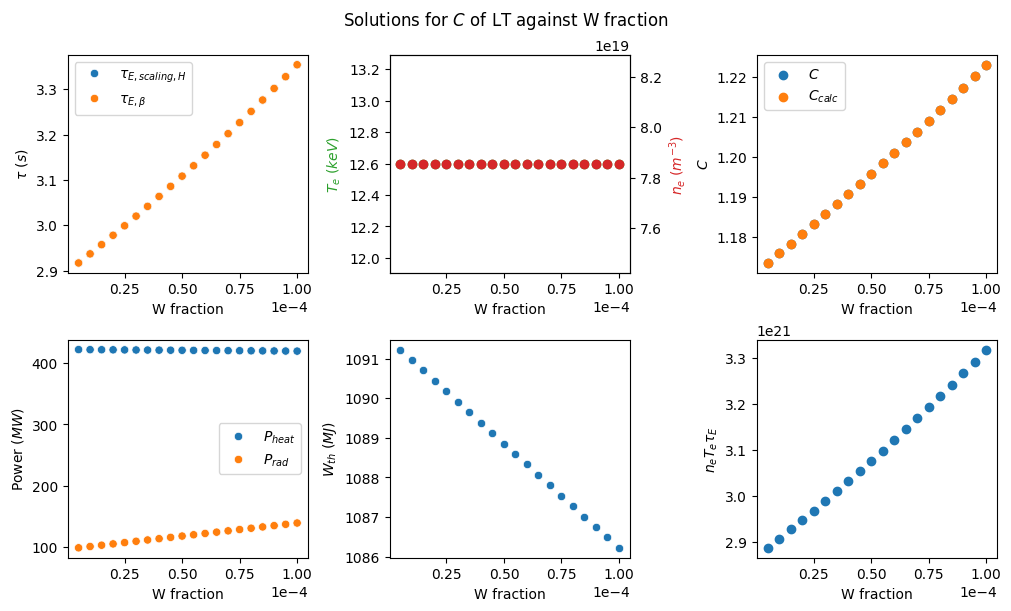

In [9]:
tau_e_sol_c_df_melt = tau_e_sol_c_df.melt(id_vars="w")
fig, ax = plt.subplots(ncols=3, nrows=2, layout="constrained")
fig.set_size_inches(10, 6)

# tau_E plot
ax0 = sns.scatterplot(
    data=tau_e_sol_c_df_melt[
        tau_e_sol_c_df_melt["variable"].isin(["tau_e_scaling_hfact", "tau_e_beta"])
    ],
    x="w",
    y="value",
    hue="variable",
    ax=ax[0, 0],
)
ax0.set_xlabel("W fraction")
ax0.set_ylabel(r"$\tau$ $(s)$")
handles, labels = ax0.get_legend_handles_labels()
my_map = {
    "tau_e_scaling_hfact": r"$\tau_{E, scaling, H}$",
    "tau_e_beta": r"$\tau_{E, \beta}$",
}
ax0.legend(handles, [my_map[l] for l in labels])
ax0.ticklabel_format(style="sci", axis="x", scilimits=(0, 0))

# te, ne plot
ax[0, 1].scatter(tau_e_sol_c_df["w"], tau_e_sol_c_df["te"], c="C2")
ax[0, 1].set_xlabel("W fraction")
ax[0, 1].set_ylabel(r"$T_e$ $(keV)$", c="C2")
ax[0, 1].ticklabel_format(style="sci", axis="x", scilimits=(0, 0))
ax1_right = ax[0, 1].twinx()
ax1_right.scatter(tau_e_sol_c_df["w"], tau_e_sol_c_df["ne"], c="C3")
ax1_right.set_ylabel(r"$n_e$ $(m^{-3})$", c="C3")

# Power plot
ax2 = sns.scatterplot(
    data=tau_e_sol_c_df_melt[tau_e_sol_c_df_melt["variable"].isin(["p_heat", "p_rad"])],
    x="w",
    y="value",
    hue="variable",
    ax=ax[1, 0],
)
ax2.set_xlabel("W fraction")
ax2.set_ylabel(r"Power $(MW)$")
handles, labels = ax2.get_legend_handles_labels()
my_map = {"p_heat": r"$P_{heat}$", "p_rad": r"$P_{rad}$"}
ax2.legend(handles, [my_map[l] for l in labels])
ax2.ticklabel_format(style="sci", axis="x", scilimits=(0, 0))

# Te, ne plot
ax3 = sns.scatterplot(
    data=tau_e_sol_c_df_melt[tau_e_sol_c_df_melt["variable"].isin(["w_th"])],
    x="w",
    y="value",
    ax=ax[1, 1],
)
ax3.ticklabel_format(style="sci", axis="x", scilimits=(0, 0))
ax3.set_xlabel("W fraction")
ax3.set_ylabel(r"$W_{th}$ $(MJ)$")

# C and C_calc plot
tau_e_scaling_hfact = tau_e_sol_c_df["tau_e_scaling_hfact"].to_numpy()
h = tau_e_sol_c_df["h"].to_numpy()
# Get scaling tau back
tau_e_scaling = tau_e_scaling_hfact / h
tau_e_beta = tau_e_sol_c_df["tau_e_beta"].to_numpy()
w = tau_e_sol_c_df["w"].to_numpy()
h_calc = tau_e_beta / tau_e_scaling

ax[0, 2].scatter(w, h, label="$C$")
ax[0, 2].scatter(w, h_calc, label="$C_{calc}$")
ax[0, 2].ticklabel_format(style="sci", axis="x", scilimits=(0, 0))
ax[0, 2].set_xlabel("W fraction")
ax[0, 2].set_ylabel(r"$C$")
ax[0, 2].legend()

# nttau plot
ax[1, 2].scatter(w, tau_e_sol_c_df["nttau"])
ax[1, 2].ticklabel_format(style="sci", axis="x", scilimits=(0, 0))
ax[1, 2].set_xlabel("W fraction")
ax[1, 2].set_ylabel(r"$n_e T_e \tau_E$")

fig.suptitle(r"Solutions for $C$ of LT against W fraction")

Plot real H-factor (calculated) against H-factor needed to fudge PPB.

H-factor is increasing to solve PPB.

### Again, but with Te, ne solutions
tau_E isn't valid without PPB being solved. Does it make a difference to solve?

Won't solve at original LT soln. Move this (and previous evaluation) to new LT soln.

In [2]:
# Extend range again
w_fracs = np.linspace(5e-6, 1e-4, 20)
tau_e_sol_ppb_tau_alpha_data = {
    "w": w_fracs,
    "tau_e_scaling_hfact": [],
    "tau_e_beta": [],
    "w_th": [],
    "p_heat": [],
    "p_rad": [],
    "te": [],
    "ne": [],
    "h": [],
    "nttau": [],
}
for w_frac in w_fracs:
    # Solution run only
    single_run = SingleRun("lt_tau_alpha_sol_IN.DAT")
    process.fortran.impurity_radiation_module.impurity_arr_frac[13] = w_frac
    single_run.run()
    tau_e_sol_ppb_tau_alpha_data["tau_e_scaling_hfact"].append(
        process.fortran.physics_variables.t_energy_confinement.item()
    )
    tau_e_sol_ppb_tau_alpha_data["tau_e_beta"].append(
        process.fortran.physics_module.t_energy_confinement_beta.item()
    )
    tau_e_sol_ppb_tau_alpha_data["w_th"].append(
        process.fortran.physics_module.e_plasma_beta.item() / 1e6
    )
    # Calc P_rad
    p_rad = (
        process.fortran.physics_variables.pden_plasma_core_rad_mw.item()
        * process.fortran.physics_variables.vol_plasma.item()
    )
    tau_e_sol_ppb_tau_alpha_data["p_heat"].append(
        process.fortran.physics_variables.p_plasma_loss_mw.item() + p_rad
    )
    tau_e_sol_ppb_tau_alpha_data["p_rad"].append(p_rad)
    tau_e_sol_ppb_tau_alpha_data["te"].append(
        process.fortran.physics_variables.te.item()
    )
    tau_e_sol_ppb_tau_alpha_data["ne"].append(
        process.fortran.physics_variables.dene.item()
    )
    tau_e_sol_ppb_tau_alpha_data["h"].append(
        process.fortran.physics_variables.hfact.item()
    )
    tau_e_sol_ppb_tau_alpha_data["nttau"].append(
        process.fortran.physics_variables.nTtau.item()
    )

The IN.DAT file does not contain any obsolete variables.
 
 **************************************************************************************************************
 ************************************************** PROCESS ***************************************************
 ************************************** Power Reactor Optimisation Code ***************************************
 **************************************************************************************************************
 
 Version : 3.1.0
 Git Tag :
 Git Branch :
Solving equality constraints using fsolve
 Date : 22/08/2025 UTC
 Time : 10:01
 User : jon
 Computer : jon-Precision-3560
 Directory : /home/jon/code/notebooks/solutions_to_process/solutions_to_process_2
 Input : /home/jon/code/notebooks/solutions_to_process/solutions_to_process_2/lt_tau_alpha_sol_IN.DAT
 Run title : generic large tokamak
 Run type : Reactor concept design: Pulsed tokamak model model, (c) UK Atomic Energy Authority
 
 **********

/home/jon/anaconda3/envs/solns2/lib/python3.11/site-packages/process/init.py:80: UserWarning: tmargmin_cs and tmargmin should not both be specified in IN.DAT tmargmin_cs has been ignored
  check_process(inputs)
/home/jon/anaconda3/envs/solns2/lib/python3.11/site-packages/process/physics.py:7259: RuntimeWarning: divide by zero encountered in divide
  * (neped / n_greenwald) ** -0.174
process.pfcoil - WARNING - Ratio of central solenoid overall current density at beginning of flat-top / end of flat-top > 1 (|f_j_cs_start_end_flat_top| > 1)
/home/jon/anaconda3/envs/solns2/lib/python3.11/site-packages/process/costs.py:2808: RuntimeWarning: invalid value encountered in sqrt
  annoam = cost_variables.ucoam[cost_variables.lsa - 1] * np.sqrt(
/home/jon/anaconda3/envs/solns2/lib/python3.11/site-packages/process/costs.py:2879: RuntimeWarning: invalid value encountered in sqrt
  annwst = cost_variables.ucwst[cost_variables.lsa - 1] * np.sqrt(
/home/jon/anaconda3/envs/solns2/lib/python3.11/site-pa

Running fixed-point problem for beta 
 ************************************ PROCESS found a consistent solution *************************************
 

beta FPP iteration
beta = array(0.03790315)
beta_calc = 0.037903147615298866
beta - beta_calc = 0.0
beta FPP iteration
beta = 0.037903147615298866
beta_calc = 0.037903147615298866
beta - beta_calc = 0.0
 Warning in routine OCMMNT :

*Cryostat roof allowance includes uppermost PF coil and outer thermal shield.
*Cryostat floor allowance includes lowermost PF coil, outer thermal shield and gravity support.
This is longer than 110 columns.
 
 ******************************************** Errors and Warnings *********************************************
 
 PROCESS status flag:   Warning messages                                  
 
 ID  LEVEL  MESSAGE
244     2   PHYSICS: Diamagnetic fraction is more than 1%, but not calculated. Consider usin
  
135     1   OUTPF: CS not using max current density: further optimisation may be possible   
  
28

process.pfcoil - WARNING - Ratio of central solenoid overall current density at beginning of flat-top / end of flat-top > 1 (|f_j_cs_start_end_flat_top| > 1)


Running fixed-point problem for beta
 
 ************************************ PROCESS found a consistent solution *************************************
 
beta FPP iteration
beta = array(0.03771535)
beta_calc = 0.037715353939348384
beta - beta_calc = 0.0
beta FPP iteration
beta = 0.037715353939348384
beta_calc = 0.037715353939348384
beta - beta_calc = 0.0
 Warning in routine OCMMNT :

*Cryostat roof allowance includes uppermost PF coil and outer thermal shield.
*Cryostat floor allowance includes lowermost PF coil, outer thermal shield and gravity support.
This is longer than 110 columns.
 
 ******************************************** Errors and Warnings *********************************************
 
 PROCESS status flag:   Warning messages                                  
 
 ID  LEVEL  MESSAGE
244     2   PHYSICS: Diamagnetic fraction is more than 1%, but not calculated. Consider usin
  
135     1   OUTPF: CS not using max current density: further optimisation may be possible   
  
28

...

Running fixed-point problem for beta 

 ************************************ PROCESS found a consistent solution *************************************
 
beta FPP iteration
beta = array(0.03477589)
beta_calc = 0.03477588946172681
beta - beta_calc = 0.0
beta FPP iteration
beta = 0.03477588946172681
beta_calc = 0.03477588946172681
beta - beta_calc = 0.0
 Warning in routine OCMMNT :

*Cryostat roof allowance includes uppermost PF coil and outer thermal shield.
*Cryostat floor allowance includes lowermost PF coil, outer thermal shield and gravity support.
This is longer than 110 columns.
 
 ******************************************** Errors and Warnings *********************************************
 
 PROCESS status flag:   Warning messages                                  
 
 ID  LEVEL  MESSAGE
244     2   PHYSICS: Diamagnetic fraction is more than 1%, but not calculated. Consider usin
  
135     1   OUTPF: CS not using max current density: further optimisation may be possible   
  
286  

process.pfcoil - WARNING - Ratio of central solenoid overall current density at beginning of flat-top / end of flat-top > 1 (|f_j_cs_start_end_flat_top| > 1)


Running fixed-point problem for beta
 
 ************************************ PROCESS found a consistent solution *************************************
 
beta FPP iteration
beta = array(0.03456948)
beta_calc = 0.03456948396762755
beta - beta_calc = 0.0
beta FPP iteration
beta = 0.03456948396762755
beta_calc = 0.03456948396762755
beta - beta_calc = 0.0
 Warning in routine OCMMNT :

*Cryostat roof allowance includes uppermost PF coil and outer thermal shield.
*Cryostat floor allowance includes lowermost PF coil, outer thermal shield and gravity support.
This is longer than 110 columns.
 
 ******************************************** Errors and Warnings *********************************************
 
 PROCESS status flag:   Warning messages                                  
 
 ID  LEVEL  MESSAGE
244     2   PHYSICS: Diamagnetic fraction is more than 1%, but not calculated. Consider usin
  
135     1   OUTPF: CS not using max current density: further optimisation may be possible   
  
286  

process.pfcoil - WARNING - Ratio of central solenoid overall current density at beginning of flat-top / end of flat-top > 1 (|f_j_cs_start_end_flat_top| > 1)


Running fixed-point problem for beta 
 ************************************ PROCESS found a consistent solution *************************************
 

beta FPP iteration
beta = array(0.0343614)
beta_calc = 0.03436140479473194
beta - beta_calc = 0.0
beta FPP iteration
beta = 0.03436140479473194
beta_calc = 0.03436140479473194
beta - beta_calc = 0.0
 Warning in routine OCMMNT :

*Cryostat roof allowance includes uppermost PF coil and outer thermal shield.
*Cryostat floor allowance includes lowermost PF coil, outer thermal shield and gravity support.
This is longer than 110 columns.
 
 ******************************************** Errors and Warnings *********************************************
 
 PROCESS status flag:   Warning messages                                  
 
 ID  LEVEL  MESSAGE
244     2   PHYSICS: Diamagnetic fraction is more than 1%, but not calculated. Consider usin
  
135     1   OUTPF: CS not using max current density: further optimisation may be possible   
  
286   

In [3]:
tau_e_sol_ppb_tau_alpha_df = pd.DataFrame(tau_e_sol_ppb_tau_alpha_data)
# tau_e_sol_ppb_tau_alpha_df

Text(0.5, 0.98, 'Solutions for $\\{T_e, n_e\\}$ of LT against W fraction')

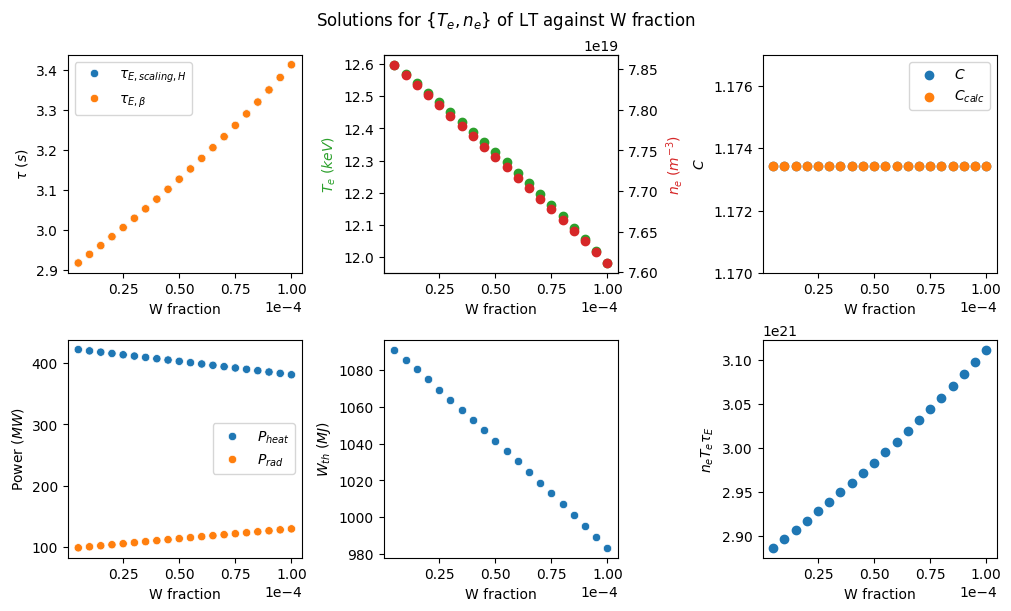

In [4]:
tau_e_sol_ppb_tau_alpha_df_melt = tau_e_sol_ppb_tau_alpha_df.melt(id_vars="w")
fig, ax = plt.subplots(ncols=3, nrows=2, layout="constrained")
fig.set_size_inches(10, 6)

# tau_E plot
ax0 = sns.scatterplot(
    data=tau_e_sol_ppb_tau_alpha_df_melt[
        tau_e_sol_ppb_tau_alpha_df_melt["variable"].isin(
            ["tau_e_scaling_hfact", "tau_e_beta"]
        )
    ],
    x="w",
    y="value",
    hue="variable",
    ax=ax[0, 0],
)
ax0.set_xlabel("W fraction")
ax0.set_ylabel(r"$\tau$ $(s)$")
handles, labels = ax0.get_legend_handles_labels()
my_map = {
    "tau_e_scaling_hfact": r"$\tau_{E, scaling, H}$",
    "tau_e_beta": r"$\tau_{E, \beta}$",
}
ax0.legend(handles, [my_map[l] for l in labels])
ax0.ticklabel_format(style="sci", axis="x", scilimits=(0, 0))

# te, ne plot
ax[0, 1].scatter(
    tau_e_sol_ppb_tau_alpha_df["w"], tau_e_sol_ppb_tau_alpha_df["te"], c="C2"
)
ax[0, 1].set_xlabel("W fraction")
ax[0, 1].set_ylabel(r"$T_e$ $(keV)$", c="C2")
ax[0, 1].ticklabel_format(style="sci", axis="x", scilimits=(0, 0))
ax1_right = ax[0, 1].twinx()
ax1_right.scatter(
    tau_e_sol_ppb_tau_alpha_df["w"], tau_e_sol_ppb_tau_alpha_df["ne"], c="C3"
)
ax1_right.set_ylabel(r"$n_e$ $(m^{-3})$", c="C3")

# Power plot
ax2 = sns.scatterplot(
    data=tau_e_sol_ppb_tau_alpha_df_melt[
        tau_e_sol_ppb_tau_alpha_df_melt["variable"].isin(["p_heat", "p_rad"])
    ],
    x="w",
    y="value",
    hue="variable",
    ax=ax[1, 0],
)
ax2.set_xlabel("W fraction")
ax2.set_ylabel(r"Power $(MW)$")
handles, labels = ax2.get_legend_handles_labels()
my_map = {"p_heat": r"$P_{heat}$", "p_rad": r"$P_{rad}$"}
ax2.legend(handles, [my_map[l] for l in labels])
ax2.ticklabel_format(style="sci", axis="x", scilimits=(0, 0))

# Te, ne plot
ax3 = sns.scatterplot(
    data=tau_e_sol_ppb_tau_alpha_df_melt[
        tau_e_sol_ppb_tau_alpha_df_melt["variable"].isin(["w_th"])
    ],
    x="w",
    y="value",
    ax=ax[1, 1],
)
ax3.ticklabel_format(style="sci", axis="x", scilimits=(0, 0))
ax3.set_xlabel("W fraction")
ax3.set_ylabel(r"$W_{th}$ $(MJ)$")

tau_e_scaling_hfact = tau_e_sol_ppb_tau_alpha_df["tau_e_scaling_hfact"].to_numpy()
h = tau_e_sol_ppb_tau_alpha_df["h"].to_numpy()
# Get scaling tau back
tau_e_scaling = tau_e_scaling_hfact / h
tau_e_beta = tau_e_sol_ppb_tau_alpha_df["tau_e_beta"].to_numpy()
w = tau_e_sol_ppb_tau_alpha_df["w"].to_numpy()
h_calc = tau_e_beta / tau_e_scaling

ax[0, 2].scatter(w, h, label="$C$")
ax[0, 2].scatter(w, h_calc, label="$C_{calc}$")
ax[0, 2].ticklabel_format(style="sci", axis="x", scilimits=(0, 0))
ax[0, 2].set_xlabel("W fraction")
ax[0, 2].set_ylabel(r"$C$")
ax[0, 2].legend()
ax[0, 2].set_ylim(1.17, 1.177)

# nttau plot
ax[1, 2].scatter(w, tau_e_sol_ppb_tau_alpha_df["nttau"])
ax[1, 2].ticklabel_format(style="sci", axis="x", scilimits=(0, 0))
ax[1, 2].set_xlabel("W fraction")
ax[1, 2].set_ylabel(r"$n_e T_e \tau_E$")

fig.suptitle(r"Solutions for $\{T_e, n_e\}$ of LT against W fraction")

What about H-factor?

## Differences between tau_Es
Why the difference between tau_E_scaling_H and tau_E_beta?

tau_E_beta

t_energy_confinement_beta = e_plasma_beta_thermal / p_plasma_loss_mw

t_energy_confinement_beta / t_energy_confinement =  3.53401032102467072 / 3.09930907204448269 = 1.1402574699313335

i.e. tau_E_beta / tau_E_scaling_H = 1.14

Should be the same. Check beta ratios:

beta / beta_thermal

4.44327511396805305e-02 / 3.89672664485030 = 1.1402583550067689

Same ratio.

Fixed now: changed e_plasma_beta to e_plasma_beta_thermal.




## Alternative tau_E experiment

In [3]:
# Extend range again
w_fracs = np.linspace(5e-6, 1e-4, 20)
tau_e_sol_ppb_tau_alpha_alt_data = {
    "w": w_fracs,
    "tau_e_scaling_hfact": [],
    "tau_e_beta": [],
    "w_th": [],
    "p_heat": [],
    "p_rad": [],
    "te": [],
    "ne": [],
    "h": [],
    "nttau": [],
}
for w_frac in w_fracs:
    # Solution run only
    single_run = SingleRun("lt_tau_alpha_sol_IN.DAT")
    process.fortran.impurity_radiation_module.impurity_arr_frac[13] = w_frac
    single_run.run()
    tau_e_sol_ppb_tau_alpha_alt_data["tau_e_scaling_hfact"].append(
        process.fortran.physics_variables.t_energy_confinement.item()
    )
    tau_e_sol_ppb_tau_alpha_alt_data["tau_e_beta"].append(
        process.fortran.physics_module.t_energy_confinement_beta.item()
    )
    tau_e_sol_ppb_tau_alpha_alt_data["w_th"].append(
        process.fortran.physics_module.e_plasma_beta.item() / 1e6
    )
    # Calc P_rad
    p_rad = (
        process.fortran.physics_variables.pden_plasma_core_rad_mw.item()
        * process.fortran.physics_variables.vol_plasma.item()
    )
    tau_e_sol_ppb_tau_alpha_alt_data["p_heat"].append(
        process.fortran.physics_variables.p_plasma_loss_mw.item() + p_rad
    )
    tau_e_sol_ppb_tau_alpha_alt_data["p_rad"].append(p_rad)
    tau_e_sol_ppb_tau_alpha_alt_data["te"].append(
        process.fortran.physics_variables.te.item()
    )
    tau_e_sol_ppb_tau_alpha_alt_data["ne"].append(
        process.fortran.physics_variables.dene.item()
    )
    tau_e_sol_ppb_tau_alpha_alt_data["h"].append(
        process.fortran.physics_variables.hfact.item()
    )
    tau_e_sol_ppb_tau_alpha_alt_data["nttau"].append(
        process.fortran.physics_variables.nTtau.item()
    )

The IN.DAT file does not contain any obsolete variables.
 
 **************************************************************************************************************
 ************************************************** PROCESS ***************************************************
 ************************************** Power Reactor Optimisation Code ***************************************
 **************************************************************************************************************
 
 Version : 3.1.0
 Git Tag :
 Git Branch :
 Date : 22/08/2025 UTC
 Time : 17:16
 User : jon
 Computer : jon-Precision-3560
 Directory : /home/jon/code/notebooks/solutions_to_process/solutions_to_process_2
 Input : /home/jon/code/notebooks/solutions_to_process/solutions_to_process_2/lt_tau_alpha_sol_IN.DAT
 Run title : generic large tokamak
 Run type : Reactor concept design: Pulsed tokamak model model, (c) UK Atomic Energy Authority
 
 ****************************************************

/home/jon/anaconda3/envs/solns2/lib/python3.11/site-packages/process/init.py:80: UserWarning: tmargmin_cs and tmargmin should not both be specified in IN.DAT tmargmin_cs has been ignored
  check_process(inputs)
/home/jon/anaconda3/envs/solns2/lib/python3.11/site-packages/process/physics.py:7259: RuntimeWarning: divide by zero encountered in divide
  * (neped / n_greenwald) ** -0.174
process.pfcoil - WARNING - Ratio of central solenoid overall current density at beginning of flat-top / end of flat-top > 1 (|f_j_cs_start_end_flat_top| > 1)
/home/jon/anaconda3/envs/solns2/lib/python3.11/site-packages/process/costs.py:2808: RuntimeWarning: invalid value encountered in sqrt
  annoam = cost_variables.ucoam[cost_variables.lsa - 1] * np.sqrt(
/home/jon/anaconda3/envs/solns2/lib/python3.11/site-packages/process/costs.py:2879: RuntimeWarning: invalid value encountered in sqrt
  annwst = cost_variables.ucwst[cost_variables.lsa - 1] * np.sqrt(
/home/jon/anaconda3/envs/solns2/lib/python3.11/site-pa

Running fixed-point problem for beta 
 ************************************ PROCESS found a consistent solution *************************************
 

beta FPP iteration
beta = array(0.03790315)
beta_calc = 0.037903147615298866
beta - beta_calc = 0.0
beta FPP iteration
beta = 0.037903147615298866
beta_calc = 0.037903147615298866
beta - beta_calc = 0.0
 Warning in routine OCMMNT :

*Cryostat roof allowance includes uppermost PF coil and outer thermal shield.
*Cryostat floor allowance includes lowermost PF coil, outer thermal shield and gravity support.
This is longer than 110 columns.
 
 ******************************************** Errors and Warnings *********************************************
 
 PROCESS status flag:   Warning messages                                  
 
 ID  LEVEL  MESSAGE
244     2   PHYSICS: Diamagnetic fraction is more than 1%, but not calculated. Consider usin
  
135     1   OUTPF: CS not using max current density: further optimisation may be possible   
  
28

process.pfcoil - WARNING - Ratio of central solenoid overall current density at beginning of flat-top / end of flat-top > 1 (|f_j_cs_start_end_flat_top| > 1)


Running fixed-point problem for beta 
 ************************************ PROCESS found a consistent solution *************************************
 

beta FPP iteration
beta = array(0.03771535)
beta_calc = 0.037715353939348384
beta - beta_calc = 0.0
beta FPP iteration
beta = 0.037715353939348384
beta_calc = 0.037715353939348384
beta - beta_calc = 0.0
 Warning in routine OCMMNT :

*Cryostat roof allowance includes uppermost PF coil and outer thermal shield.
*Cryostat floor allowance includes lowermost PF coil, outer thermal shield and gravity support.
This is longer than 110 columns.
 
 ******************************************** Errors and Warnings *********************************************
 
 PROCESS status flag:   Warning messages                                  
 
 ID  LEVEL  MESSAGE
244     2   PHYSICS: Diamagnetic fraction is more than 1%, but not calculated. Consider usin
  
135     1   OUTPF: CS not using max current density: further optimisation may be possible   
  
28

...

Running fixed-point problem for beta
 
 ************************************ PROCESS found a consistent solution *************************************
 
beta FPP iteration
beta = array(0.03477589)
beta_calc = 0.03477588946172681
beta - beta_calc = 0.0
beta FPP iteration
beta = 0.03477588946172681
beta_calc = 0.03477588946172681
beta - beta_calc = 0.0
 Warning in routine OCMMNT :

*Cryostat roof allowance includes uppermost PF coil and outer thermal shield.
*Cryostat floor allowance includes lowermost PF coil, outer thermal shield and gravity support.
This is longer than 110 columns.
 
 ******************************************** Errors and Warnings *********************************************
 
 PROCESS status flag:   Warning messages                                  
 
 ID  LEVEL  MESSAGE
244     2   PHYSICS: Diamagnetic fraction is more than 1%, but not calculated. Consider usin
  
135     1   OUTPF: CS not using max current density: further optimisation may be possible   
  
286  

process.pfcoil - WARNING - Ratio of central solenoid overall current density at beginning of flat-top / end of flat-top > 1 (|f_j_cs_start_end_flat_top| > 1)


Running fixed-point problem for beta
 
 ************************************ PROCESS found a consistent solution *************************************
 
beta FPP iteration
beta = array(0.03456948)
beta_calc = 0.03456948396762755
beta - beta_calc = 0.0
beta FPP iteration
beta = 0.03456948396762755
beta_calc = 0.03456948396762755
beta - beta_calc = 0.0
 Warning in routine OCMMNT :

*Cryostat roof allowance includes uppermost PF coil and outer thermal shield.
*Cryostat floor allowance includes lowermost PF coil, outer thermal shield and gravity support.
This is longer than 110 columns.
 
 ******************************************** Errors and Warnings *********************************************
 
 PROCESS status flag:   Warning messages                                  
 
 ID  LEVEL  MESSAGE
244     2   PHYSICS: Diamagnetic fraction is more than 1%, but not calculated. Consider usin
  
135     1   OUTPF: CS not using max current density: further optimisation may be possible   
  
286  

process.pfcoil - WARNING - Ratio of central solenoid overall current density at beginning of flat-top / end of flat-top > 1 (|f_j_cs_start_end_flat_top| > 1)


Running fixed-point problem for beta 
 ************************************ PROCESS found a consistent solution *************************************
 

beta FPP iteration
beta = array(0.0343614)
beta_calc = 0.03436140479473194
beta - beta_calc = 0.0
beta FPP iteration
beta = 0.03436140479473194
beta_calc = 0.03436140479473194
beta - beta_calc = 0.0
 Warning in routine OCMMNT :

*Cryostat roof allowance includes uppermost PF coil and outer thermal shield.
*Cryostat floor allowance includes lowermost PF coil, outer thermal shield and gravity support.
This is longer than 110 columns.
 
 ******************************************** Errors and Warnings *********************************************
 
 PROCESS status flag:   Warning messages                                  
 
 ID  LEVEL  MESSAGE
244     2   PHYSICS: Diamagnetic fraction is more than 1%, but not calculated. Consider usin
  
135     1   OUTPF: CS not using max current density: further optimisation may be possible   
  
286   

In [9]:
tau_e_sol_ppb_tau_alpha_alt_df = pd.DataFrame(tau_e_sol_ppb_tau_alpha_alt_data)
# tau_e_sol_ppb_tau_alpha_alt_df

Text(0.5, 0.98, 'Solutions for $\\{T_e, n_e\\}$ of LT against W fraction (alt $\\tau_E$)')

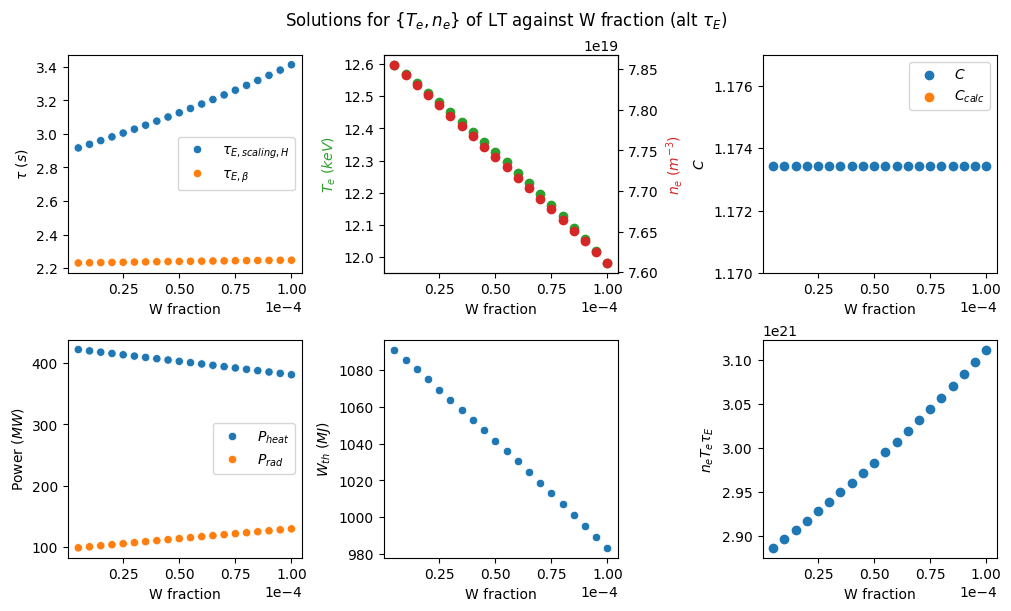

In [5]:
tau_e_sol_ppb_tau_alpha_alt_df_melt = tau_e_sol_ppb_tau_alpha_alt_df.melt(id_vars="w")
fig, ax = plt.subplots(ncols=3, nrows=2, layout="constrained")
fig.set_size_inches(10, 6)

# tau_E plot
ax0 = sns.scatterplot(
    data=tau_e_sol_ppb_tau_alpha_alt_df_melt[
        tau_e_sol_ppb_tau_alpha_alt_df_melt["variable"].isin(
            ["tau_e_scaling_hfact", "tau_e_beta"]
        )
    ],
    x="w",
    y="value",
    hue="variable",
    ax=ax[0, 0],
)
ax0.set_xlabel("W fraction")
ax0.set_ylabel(r"$\tau$ $(s)$")
handles, labels = ax0.get_legend_handles_labels()
my_map = {
    "tau_e_scaling_hfact": r"$\tau_{E, scaling, H}$",
    "tau_e_beta": r"$\tau_{E, \beta}$",
}
ax0.legend(handles, [my_map[l] for l in labels])
ax0.ticklabel_format(style="sci", axis="x", scilimits=(0, 0))

# te, ne plot
ax[0, 1].scatter(
    tau_e_sol_ppb_tau_alpha_alt_df["w"], tau_e_sol_ppb_tau_alpha_alt_df["te"], c="C2"
)
ax[0, 1].set_xlabel("W fraction")
ax[0, 1].set_ylabel(r"$T_e$ $(keV)$", c="C2")
ax[0, 1].ticklabel_format(style="sci", axis="x", scilimits=(0, 0))
ax1_right = ax[0, 1].twinx()
ax1_right.scatter(
    tau_e_sol_ppb_tau_alpha_alt_df["w"], tau_e_sol_ppb_tau_alpha_alt_df["ne"], c="C3"
)
ax1_right.set_ylabel(r"$n_e$ $(m^{-3})$", c="C3")

# Power plot
ax2 = sns.scatterplot(
    data=tau_e_sol_ppb_tau_alpha_alt_df_melt[
        tau_e_sol_ppb_tau_alpha_alt_df_melt["variable"].isin(["p_heat", "p_rad"])
    ],
    x="w",
    y="value",
    hue="variable",
    ax=ax[1, 0],
)
ax2.set_xlabel("W fraction")
ax2.set_ylabel(r"Power $(MW)$")
handles, labels = ax2.get_legend_handles_labels()
my_map = {"p_heat": r"$P_{heat}$", "p_rad": r"$P_{rad}$"}
ax2.legend(handles, [my_map[l] for l in labels])
ax2.ticklabel_format(style="sci", axis="x", scilimits=(0, 0))

# Te, ne plot
ax3 = sns.scatterplot(
    data=tau_e_sol_ppb_tau_alpha_alt_df_melt[
        tau_e_sol_ppb_tau_alpha_alt_df_melt["variable"].isin(["w_th"])
    ],
    x="w",
    y="value",
    ax=ax[1, 1],
)
ax3.ticklabel_format(style="sci", axis="x", scilimits=(0, 0))
ax3.set_xlabel("W fraction")
ax3.set_ylabel(r"$W_{th}$ $(MJ)$")

tau_e_scaling_hfact = tau_e_sol_ppb_tau_alpha_alt_df["tau_e_scaling_hfact"].to_numpy()
h = tau_e_sol_ppb_tau_alpha_alt_df["h"].to_numpy()
# Get scaling tau back
tau_e_scaling = tau_e_scaling_hfact / h
tau_e_beta = tau_e_sol_ppb_tau_alpha_alt_df["tau_e_beta"].to_numpy()
w = tau_e_sol_ppb_tau_alpha_alt_df["w"].to_numpy()
h_calc = tau_e_beta / tau_e_scaling

ax[0, 2].scatter(w, h, label="$C$")
ax[0, 2].scatter(w, h_calc, label="$C_{calc}$")
ax[0, 2].ticklabel_format(style="sci", axis="x", scilimits=(0, 0))
ax[0, 2].set_xlabel("W fraction")
ax[0, 2].set_ylabel(r"$C$")
ax[0, 2].legend()
ax[0, 2].set_ylim(1.17, 1.177)

# nttau plot
ax[1, 2].scatter(w, tau_e_sol_ppb_tau_alpha_alt_df["nttau"])
ax[1, 2].ticklabel_format(style="sci", axis="x", scilimits=(0, 0))
ax[1, 2].set_xlabel("W fraction")
ax[1, 2].set_ylabel(r"$n_e T_e \tau_E$")

fig.suptitle(r"Solutions for $\{T_e, n_e\}$ of LT against W fraction (alt $\tau_E$)")